# Results NVV-Pipeline Evaluation Experiment - Full-GT and Part-GT
- yml: environment.yml
- env: nvv_isolation_pipeline
- last updated: 29.04.2026


## RQ - Experiment Mapping Table
| RQ | Experiment | Full-GT Mode | Part-GT Mode | Result |
|---|---|---|---|---|
| RQ1 Capability | Baseline vs. best configuration set | Greedy forward selection + union evaluation (F1-based) | Reuse of selected set + union evaluation | Best achievable score vs. baseline |
| RQ2 Sensitivity | Configuration ranking (single best) | Ranking based on full-GT metrics | Ranking based on part-GT metrics | Best single configuration |
|  | Configuration combination (selected set) | Greedy forward selection + union evaluation | Reuse of selected set + union evaluation | Best-performing configuration set |
|  | Audio derivative aggregation | Group-wise comparison by ASR input audio derivative | Distribution-based comparison across groups | Best-performing audio derivative group |
| RQ3 NVV Coverage | Coverage analysis | Global and label-level analysis | Global and Event-level analysis | Coverage across categories or events |

## Setup
- Imports
- Config

In [ ]:
#Setup
import os
import sys
from pathlib import Path

project_root = Path(os.getcwd()).parent
sys.path.append(str(project_root))
results_dir = project_root / "data" / "results"

import pandas as pd
import matplotlib.pyplot as plt

from config.load_config import load_config
from config.path_factory import print_paths

from evaluation.analysis_loader import load_and_compare_workspaces
from evaluation.analysis_tables import build_rq1_capability_tables


cfg_path_nvs_full_gt = project_root / "experiments" / "pipeline_evaluation" / "config_nvs38k_full_gt.yaml"
cfg_path_nvs_part_gt = project_root / "experiments" / "pipeline_evaluation" / "config_nvs38k_part_gt.yaml"
cfg_path_vocal_part_gt = project_root / "experiments" / "pipeline_evaluation" / "config_vocal_part_gt.yaml"

rq_results_dir = results_dir

config = load_config(cfg_path_nvs_full_gt)

# print_paths(cfg_path_nvs_full_gt)

## Collect Pipeline Evaluation Experiment Results 
- Experiment specs for comparison


In [2]:
# specification of full run evaluation experiments to load and compare (all settings)
specs = [
    {
        "label": "NVS-38K_EN | full_gt",
        "cfg_path": cfg_path_nvs_full_gt,
        "dataset_name": "NVS-38K_EN",
        "mode": "full_gt",
    },
    {
        "label": "NVS-38K_EN | part_gt",
        "cfg_path": cfg_path_nvs_part_gt,
        "dataset_name": "NVS-38K_EN",
        "mode": "part_gt",
    },
    {
        "label": "VOCAL_RA1 | part_gt",
        "cfg_path": cfg_path_vocal_part_gt,
        "dataset_name": "VOCAL_RA1",
        "mode": "part_gt",
    },
    {
        "label": "VOCAL_RA2 | part_gt",
        "cfg_path": cfg_path_vocal_part_gt,
        "dataset_name": "VOCAL_RA2",
        "mode": "part_gt",
    },
]

analysis_bundle = load_and_compare_workspaces(
    specs=specs,
    param_names=[],
    param_pairs=[],
)

bundles_by_spec = analysis_bundle["bundles_by_spec"]
views_by_spec = analysis_bundle["views_by_spec"]
views = analysis_bundle["combined_views"]
setting_order = analysis_bundle["setting_order"]

bundles_by_spec.keys()


dict_keys(['NVS-38K_EN | full_gt', 'NVS-38K_EN | part_gt', 'VOCAL_RA1 | part_gt', 'VOCAL_RA2 | part_gt'])

In [3]:
def setting_to_filename_tag(setting: str) -> str:
    """
    Convert a setting label like 'NVS-38K_EN | full_gt'
    into a filename-safe tag like 'NVS_38K_EN_full_gt'.

    Args:
        setting: Setting label.

    Returns:
        Filename-safe tag.
    """
    if " | " not in setting:
        raise ValueError(f"Unexpected setting format: {setting}")

    dataset_name, mode = setting.split(" | ", maxsplit=1)

    dataset_name = dataset_name.strip().replace("-", "_").replace(" ", "_")
    mode = mode.strip().replace("-", "_").replace(" ", "_")

    return f"{dataset_name}_{mode}"

## RQ1 Pipeline Capability

In [ ]:

# --- collect RQ1 tables from the loaded settings ---
rq1_all = pd.concat(
    [
        bundle["results"]["rq1"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq1_tables = build_rq1_capability_tables(rq1_all)

print("RQ1 Capability Table (Full-GT):")
display(rq1_tables["full_gt"])

print("RQ1 Capability Table (Part-GT):")
display(rq1_tables["part_gt"])

RQ1 Capability Table (Full-GT):


,Setting,System,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN | full_gt,Baseline,0.158532,0.230898,0.203614,0.203614,1.520915
1,NVS-38K_EN | full_gt,Best Selected Set,0.198103,0.270496,0.237039,0.237039,1.517568
2,NVS-38K_EN | full_gt,Δ vs Baseline,0.039571,0.039598,0.033425,0.033425,-0.003346


RQ1 Capability Table (Part-GT):


,Setting,System,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN | part_gt,Baseline,0.230898,0.203614,0.203614,1.520915
1,NVS-38K_EN | part_gt,Best Selected Set,0.270496,0.237039,0.237039,1.517568
2,NVS-38K_EN | part_gt,Δ vs Baseline,0.039598,0.033425,0.033425,-0.003346
3,VOCAL_RA1 | part_gt,Baseline,0.199631,0.178218,0.357947,1.845932
4,VOCAL_RA1 | part_gt,Best Selected Set,0.274072,0.240137,0.458683,3.098171
5,VOCAL_RA1 | part_gt,Δ vs Baseline,0.074441,0.061919,0.100736,1.252239
6,VOCAL_RA2 | part_gt,Baseline,0.187419,0.160165,0.255922,5.254622
7,VOCAL_RA2 | part_gt,Best Selected Set,0.247310,0.214327,0.329348,6.093335
8,VOCAL_RA2 | part_gt,Δ vs Baseline,0.059891,0.054162,0.073426,0.838713


In [5]:
# RQ1 appendix table for Word/Excel
full = rq1_tables["full_gt"].copy()
part = rq1_tables["part_gt"].copy()

systems_order = ["Baseline", "Best Selected Set", "Δ vs Baseline"]

# keep only relevant rows and order them
full = full[full["System"].isin(systems_order)].copy()
part = part[part["System"].isin(systems_order)].copy()

full["System"] = pd.Categorical(full["System"], categories=systems_order, ordered=True)
part["System"] = pd.Categorical(part["System"], categories=systems_order, ordered=True)

full = full.sort_values(["Setting", "System"])
part = part.sort_values(["Setting", "System"])

# select settings
nvs_full = full[full["Setting"] == "NVS-38K_EN | full_gt"]
nvs_part = part[part["Setting"] == "NVS-38K_EN | part_gt"]
ra1 = part[part["Setting"] == "VOCAL_RA1 | part_gt"]
ra2 = part[part["Setting"] == "VOCAL_RA2 | part_gt"]

# build final table with grouped headers
rq1_appendix = pd.DataFrame({
    ("", "System"): systems_order,

    ("NVS-38K_EN | full_gt", "F1"): nvs_full["F1"].tolist(),
    ("NVS-38K_EN | full_gt", "Recall"): nvs_full["Recall"].tolist(),
    ("NVS-38K_EN | full_gt", "EOS Recall"): nvs_full["EOS Recall"].tolist(),
    ("NVS-38K_EN | full_gt", "Mean EOS TP"): nvs_full["Mean EOS TP"].tolist(),
    ("NVS-38K_EN | full_gt", "Insertion Rate"): nvs_full["Insertion Rate"].tolist(),


    ("NVS-38K_EN | part_gt", "Recall"): nvs_part["Recall"].tolist(),
    ("NVS-38K_EN | part_gt", "EOS Recall"): nvs_part["EOS Recall"].tolist(),
    ("NVS-38K_EN | part_gt", "Mean EOS TP"): nvs_part["Mean EOS TP"].tolist(),
    ("NVS-38K_EN | part_gt", "Insertion Rate"): nvs_part["Insertion Rate"].tolist(),


    ("VOCAL_RA1 | part_gt", "Recall"): ra1["Recall"].tolist(),
    ("VOCAL_RA1 | part_gt", "EOS Recall"): ra1["EOS Recall"].tolist(),
    ("VOCAL_RA1 | part_gt", "Mean EOS TP"): ra1["Mean EOS TP"].tolist(),
    ("VOCAL_RA1 | part_gt", "Insertion Rate"): ra1["Insertion Rate"].tolist(),

    ("VOCAL_RA2 | part_gt", "Recall"): ra2["Recall"].tolist(),
    ("VOCAL_RA2 | part_gt", "EOS Recall"): ra2["EOS Recall"].tolist(),
    ("VOCAL_RA2 | part_gt", "Mean EOS TP"): ra2["Mean EOS TP"].tolist(),
    ("VOCAL_RA2 | part_gt", "Insertion Rate"): ra2["Insertion Rate"].tolist(),
})

rq1_appendix.columns = pd.MultiIndex.from_tuples(rq1_appendix.columns)

# round only for presentation
rq1_appendix = rq1_appendix.round(3)

rq1_appendix

NVS-38K_EN | full_gt                                \
              System                   F1 Recall EOS Recall Mean EOS TP   
0           Baseline                0.159  0.231      0.204       0.204   
1  Best Selected Set                0.198  0.270      0.237       0.237   
2      Δ vs Baseline                0.040  0.040      0.033       0.033   

                 NVS-38K_EN | part_gt                                        \
  Insertion Rate               Recall EOS Recall Mean EOS TP Insertion Rate   
0          1.521                0.231      0.204       0.204          1.521   
1          1.518                0.270      0.237       0.237          1.518   
2         -0.003                0.040      0.033       0.033         -0.003   

  VOCAL_RA1 | part_gt                                        \
               Recall EOS Recall Mean EOS TP Insertion Rate   
0               0.200      0.178       0.358          1.846   
1               0.274      0.240       0.459          3.098   
2               0.074      0.062       0.101          1.252   

  VOCAL_RA2 | part_gt                                        
               Recall EOS Recall Mean EOS TP Insertion Rate  
0               0.187      0.160       0.256          5.255  
1               0.247      0.214       0.329          6.093  
2               0.060      0.054       0.073          0.839

In [6]:
# save RQ1 appendix table for Word/Excel
rq1_path = rq_results_dir / "rq1_capability_appendix_table.xlsx"


with pd.ExcelWriter(rq1_path, engine="openpyxl") as writer:
    rq1_appendix.to_excel(writer, sheet_name="RQ1 Capability", merge_cells=True)

print(rq1_path)

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq1_capability_appendix_table.xlsx


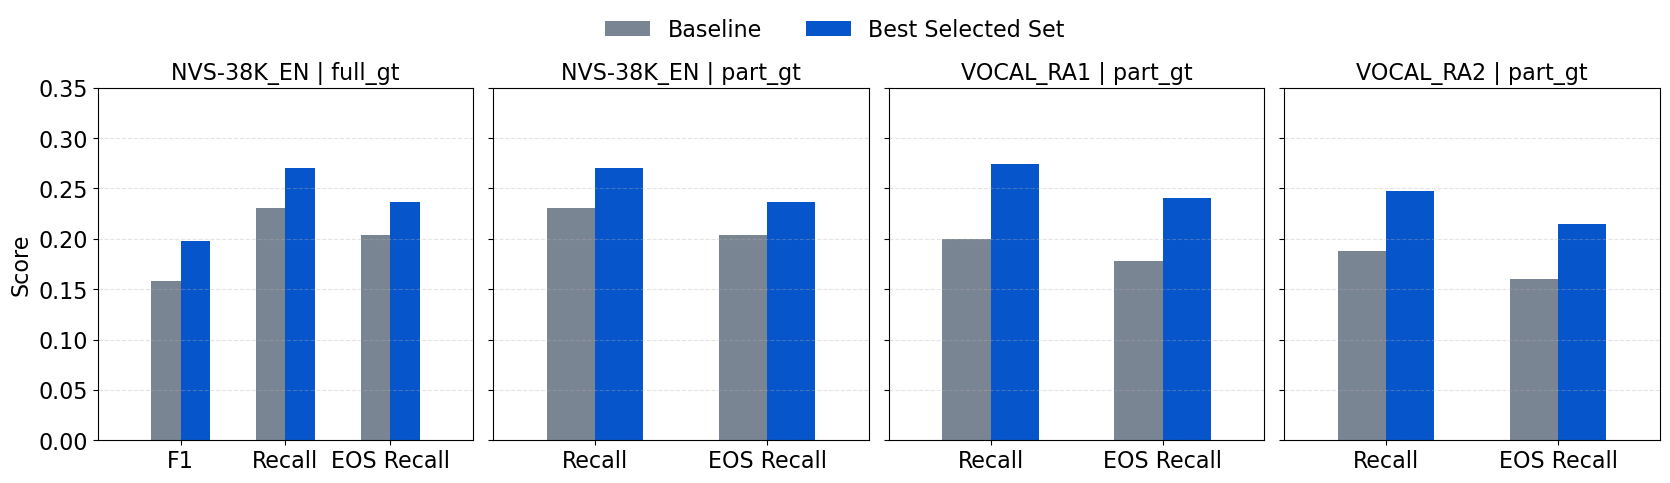

In [7]:
from evaluation.rq_plots import plot_rq1_all_settings_grouped_bars

rq1_fig_all_settings = plot_rq1_all_settings_grouped_bars(
    rq1_tables["full_gt"],
    rq1_tables["part_gt"],
    setting_order=setting_order,
    colors={
        "Baseline": "#7A8594",
        "Best Single": "#719AD4",
        "Best Selected Set": "#0655CB",
    },
)
plt.show()

rq1_fig_all_settings_path = rq_results_dir / "rq1_capability_all_settings.png"

rq1_fig_all_settings.savefig(
    rq1_fig_all_settings_path,
    dpi=300,
    bbox_inches="tight"
)


## RQ2 Ranking Configuration: Single best

In [8]:
from evaluation.analysis_tables import build_rq2a_single_ranking_tables

rq2a_single_all = pd.concat(
    [
        bundle["results"]["rq2a_single"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq2a_single_tables_top_5 = build_rq2a_single_ranking_tables(
    rq2a_single_all,
    top_k=5,
)

print("RQ2 Sensitivity to Configuration Changes: Single Configuration Ranking Tables:")
for setting_name, df_table in rq2a_single_tables_top_5.items():
    print(f"\n=== {setting_name} ===")
    display(df_table.round(3))

RQ2 Sensitivity to Configuration Changes: Single Configuration Ranking Tables:

=== NVS-38K_EN | full_gt ===


,Rank,VAD Mask,ASR Audio Input,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,1,std_vocals,std_vocals_norm,0.193,0.260,0.228,0.228,1.484
1,2,std_vocals_norm,std_vocals_norm,0.189,0.258,0.226,0.226,1.495
2,3,std,std_vocals_norm,0.183,0.250,0.219,0.219,1.495
3,4,original,std_vocals_norm,0.182,0.247,0.216,0.216,1.480
4,5,original,std,0.161,0.233,0.205,0.205,1.532



=== NVS-38K_EN | part_gt ===


,Rank,VAD Mask,ASR Audio Input,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,1,std_vocals,std_vocals_norm,0.260,0.228,0.228,1.484
1,2,std_vocals_norm,std_vocals_norm,0.258,0.226,0.226,1.495
2,3,std,std_vocals_norm,0.250,0.219,0.219,1.495
3,4,original,std_vocals_norm,0.247,0.216,0.216,1.480
4,5,std_vocals,std_vocals,0.237,0.211,0.211,1.510



=== VOCAL_RA1 | part_gt ===


,Rank,VAD Mask,ASR Audio Input,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,1,std_vocals_norm,std,0.236,0.207,0.401,1.758
1,2,std_vocals_norm,original,0.232,0.204,0.395,1.694
2,3,std_vocals_norm,std_vocals_norm,0.220,0.192,0.386,1.857
3,4,std_vocals,std,0.220,0.192,0.383,1.728
4,5,std_vocals,original,0.216,0.190,0.378,1.669



=== VOCAL_RA2 | part_gt ===


,Rank,VAD Mask,ASR Audio Input,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,1,std,std,0.197,0.170,0.253,4.399
1,2,original,std,0.194,0.166,0.257,5.232
2,3,original,original,0.187,0.160,0.256,5.255
3,4,std,original,0.184,0.158,0.241,5.588
4,5,std_vocals,std,0.171,0.149,0.257,3.076


In [9]:
# save full RQ2a single-ranking tables (all 42) to one Excel workbook
rq2a_ranking_path = results_dir / "rq2_sensitivity_configuration_ranking_appendix_tables.xlsx"

rq2a_single_tables_all = build_rq2a_single_ranking_tables(
    rq2a_single_all,
    top_k=42,
)

with pd.ExcelWriter(rq2a_ranking_path, engine="openpyxl") as writer:
    for setting_name, df_table in rq2a_single_tables_all.items():
        sheet_name = setting_name.replace(" | ", "_")[:31]
        df_export = df_table.round(3).copy()

        df_export.to_excel(writer, sheet_name=sheet_name, index=False)

        worksheet = writer.sheets[sheet_name]

        for col_idx, col_name in enumerate(df_export.columns, 1):
            # only format float columns (skip int like Rank)
            if pd.api.types.is_float_dtype(df_export[col_name]):
                for row in range(2, len(df_export) + 2):
                    worksheet.cell(row=row, column=col_idx).number_format = "0.000"

print(rq2a_ranking_path)

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_ranking_appendix_tables.xlsx


In [10]:
rq2_top5_clean = {}

for setting_name, df in rq2a_single_tables_top_5.items():
    df_clean = df[["Rank", "VAD Mask", "ASR Audio Input"]].copy()
    rq2_top5_clean[setting_name] = df_clean

for setting_name, df in rq2_top5_clean.items():
    print(f"\n=== {setting_name} ===")
    display(df.style.hide(axis="index").set_properties(**{"text-align": "center"}))


=== NVS-38K_EN | full_gt ===


Rank,VAD Mask,ASR Audio Input
1,std_vocals,std_vocals_norm
2,std_vocals_norm,std_vocals_norm
3,std,std_vocals_norm
4,original,std_vocals_norm
5,original,std



=== NVS-38K_EN | part_gt ===


Rank,VAD Mask,ASR Audio Input
1,std_vocals,std_vocals_norm
2,std_vocals_norm,std_vocals_norm
3,std,std_vocals_norm
4,original,std_vocals_norm
5,std_vocals,std_vocals



=== VOCAL_RA1 | part_gt ===


Rank,VAD Mask,ASR Audio Input
1,std_vocals_norm,std
2,std_vocals_norm,original
3,std_vocals_norm,std_vocals_norm
4,std_vocals,std
5,std_vocals,original



=== VOCAL_RA2 | part_gt ===


Rank,VAD Mask,ASR Audio Input
1,std,std
2,original,std
3,original,original
4,std,original
5,std_vocals,std


In [11]:
# save RQ2 top-5 configuration tables to one Excel workbook
rq2_top5_path = rq_results_dir / "rq2_sensitivity_configuration_ranking_top5_table.xlsx"

with pd.ExcelWriter(rq2_top5_path, engine="openpyxl") as writer:
    for setting_name, df in rq2_top5_clean.items():
        sheet_name = setting_name[:31]  # Excel limit for sheet names
        df_export = df.copy()
        df_export.to_excel(writer, sheet_name=sheet_name, index=False)

print(rq2_top5_path)

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_ranking_top5_table.xlsx


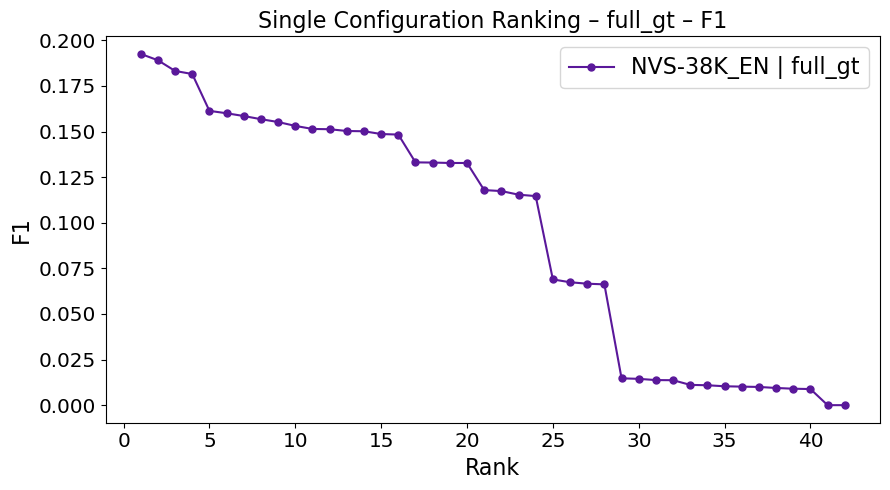

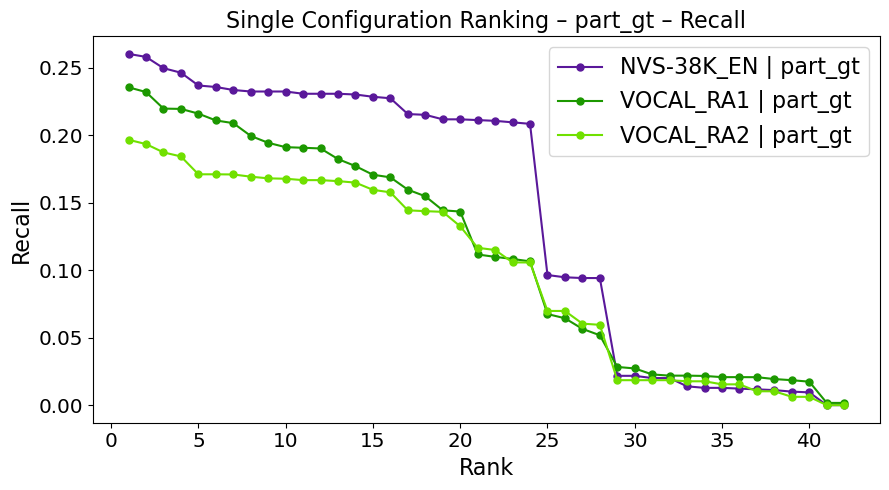

In [12]:

from evaluation.rq_plots import plot_rq2a_rank_vs_score

fig_full_gt = plot_rq2a_rank_vs_score(
    rq2a_single_all,
    mode="full_gt",
    score_col="macro_mean_f1",
    top_k=42,
    setting_order=setting_order,
)
plt.show()


fig_part_gt = plot_rq2a_rank_vs_score(
    rq2a_single_all,
    mode="part_gt",
    score_col="macro_mean_recall",
    top_k=42,
    setting_order=setting_order,
)
plt.show()


In [13]:
# save full RQ2a single-ranking tables (top 42) to png files
rq2_fig_path = results_dir
rq2_fig_full_gt = rq2_fig_path / "rq2_sensitivity_configuration_rank_vs_score_full_gt.png"
rq2_fig_part_gt = rq2_fig_path / "rq2_sensitivity_configuration_rank_vs_score_part_gt.png"

fig_full_gt.savefig(
    rq2_fig_full_gt,
    dpi=300,
    bbox_inches="tight"
)

fig_part_gt.savefig(
    rq2_fig_part_gt,
    dpi=300,
    bbox_inches="tight"
)

## RQ2 Configuration Combination: Selected Set

### Find k: Full-GT greedy forward union of complementary configurations

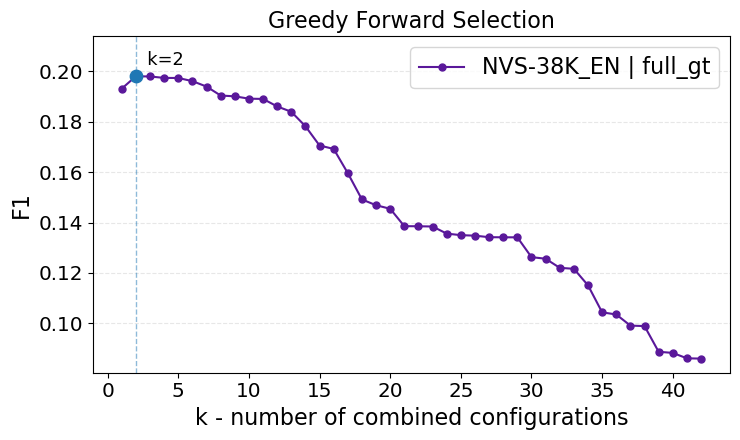

In [14]:
from evaluation.rq_plots import plot_rq2a_f1_vs_k

df_f1_vs_k = bundles_by_spec["NVS-38K_EN | full_gt"]["results"]["rq2a_f1_vs_k"]

f1_vs_k_fig = plot_rq2a_f1_vs_k(
    df_f1_vs_k,
    setting="NVS-38K_EN | full_gt",
)

plt.show()

In [15]:
# save full RQ2a single-ranking tables (top 42) to one Excel workbook
rq2_fig_path = results_dir
rq2_f1_vs_k_path = rq2_fig_path / "rq2_sensitivity_configuration_combination_f1_vs_k.png"

f1_vs_k_fig.savefig(
    rq2_f1_vs_k_path,
    dpi=300,
    bbox_inches="tight"
)


### Delta Best Single Configuration vs. Best Selected Set

In [16]:
from evaluation.analysis_tables import build_rq2a_selected_set_tables

rq2a_combination_path = results_dir / "rq2_sensitivity_configuration_combination_appendix_tables.xlsx"

rq2a_selected_all = pd.concat(
    [
        bundle["results"]["rq2a_selected_set"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq2a_selected_tables = build_rq2a_selected_set_tables(
    rq2a_single_all,
    rq2a_selected_all,
)

print("RQ2 Sensitivity to Configuration Changes: Combination of complimentary configurations (selected Set):")
for setting_name, df_table in rq2a_selected_tables.items():
    print(f"\n=== {setting_name} ===")
    display(df_table.round(3))

RQ2 Sensitivity to Configuration Changes: Combination of complimentary configurations (selected Set):

=== NVS-38K_EN | full_gt ===


,Setting,System,k,Config / Selected Set,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN | full_gt,Best Single,1,std_vocals + std_vocals_norm,0.193,0.26,0.228,0.228,1.484
1,NVS-38K_EN | full_gt,Best Selected Set,2,"[""std_vocals_vad_std_vocals_norm_asr_nlp_nvv"",...",0.198,0.27,0.237,0.237,1.518
2,NVS-38K_EN | full_gt,Δ vs Best Single,1,None,0.006,0.01,0.009,0.009,0.033



=== NVS-38K_EN | part_gt ===


,Setting,System,k,Config / Selected Set,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN | part_gt,Best Single,1,std_vocals + std_vocals_norm,0.26,0.228,0.228,1.484
1,NVS-38K_EN | part_gt,Best Selected Set,2,"[""std_vocals_vad_std_vocals_norm_asr_nlp_nvv"",...",0.27,0.237,0.237,1.518
2,NVS-38K_EN | part_gt,Δ vs Best Single,1,None,0.01,0.009,0.009,0.033



=== VOCAL_RA1 | part_gt ===


,Setting,System,k,Config / Selected Set,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,VOCAL_RA1 | part_gt,Best Single,1,std_vocals_norm + std,0.236,0.207,0.401,1.758
1,VOCAL_RA1 | part_gt,Best Selected Set,3,"[""std_vocals_norm_vad_std_asr_nlp_nvv"", ""std_v...",0.274,0.240,0.459,3.098
2,VOCAL_RA1 | part_gt,Δ vs Best Single,2,None,0.038,0.033,0.058,1.340



=== VOCAL_RA2 | part_gt ===


,Setting,System,k,Config / Selected Set,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,VOCAL_RA2 | part_gt,Best Single,1,std + std,0.197,0.170,0.253,4.399
1,VOCAL_RA2 | part_gt,Best Selected Set,3,"[""std_vad_std_asr_nlp_nvv"", ""std_vocals_vad_st...",0.247,0.214,0.329,6.093
2,VOCAL_RA2 | part_gt,Δ vs Best Single,2,None,0.051,0.044,0.076,1.694


In [17]:
rq2a_combination_path = results_dir / "rq2_sensitivity_configuration_combination_appendix_tables.xlsx"

with pd.ExcelWriter(rq2a_combination_path, engine="openpyxl") as writer:
    for setting_name, df_table in rq2a_selected_tables.items():
        sheet_name = setting_name.replace(" | ", "_")[:31]
        df_export = df_table.round(3).copy()

        df_export.to_excel(writer, sheet_name=sheet_name, index=False)

        worksheet = writer.sheets[sheet_name]

        for col_idx, col_name in enumerate(df_export.columns, 1):
            # only format float columns (skip int like Rank)
            if pd.api.types.is_float_dtype(df_export[col_name]):
                for row in range(2, len(df_export) + 2):
                    worksheet.cell(row=row, column=col_idx).number_format = "0.000"

print(rq2a_combination_path)


/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_combination_appendix_tables.xlsx


### Comparison Best Single vs Best Selected Set Barplots

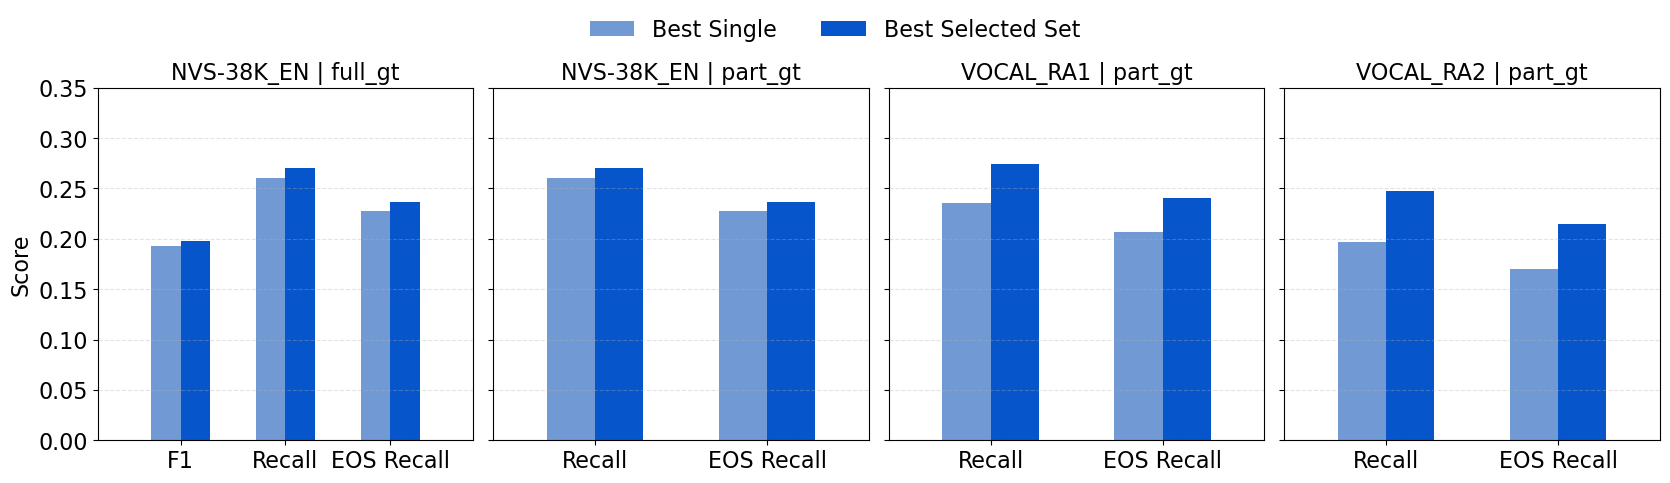

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_combination_all_settings.png


In [18]:
### Comparison Best Single vs Best Selected Set Barplots
from evaluation.rq_plots import plot_rq2a_selected_set_all_settings_grouped_bars

# combine formatted RQ2a selected-set tables into one DataFrame
rq2_selected_plot_df = pd.concat(
    rq2a_selected_tables.values(),
    ignore_index=True,
)

# split into full_gt and part_gt and keep only plotted systems
rq2_full = rq2_selected_plot_df[
    (rq2_selected_plot_df["Setting"].str.endswith("full_gt")) &
    (rq2_selected_plot_df["System"].isin(["Best Single", "Best Selected Set"]))
].copy()

rq2_part = rq2_selected_plot_df[
    (rq2_selected_plot_df["Setting"].str.endswith("part_gt")) &
    (rq2_selected_plot_df["System"].isin(["Best Single", "Best Selected Set"]))
].copy()

# optional: enforce plot order
systems_order = ["Best Single", "Best Selected Set"]

rq2_full["System"] = pd.Categorical(
    rq2_full["System"],
    categories=systems_order,
    ordered=True,
)
rq2_part["System"] = pd.Categorical(
    rq2_part["System"],
    categories=systems_order,
    ordered=True,
)

rq2_full = rq2_full.sort_values(["Setting", "System"])
rq2_part = rq2_part.sort_values(["Setting", "System"])

# plot
rq2_fig_all_settings = plot_rq2a_selected_set_all_settings_grouped_bars(
    rq2_full,
    rq2_part,
    setting_order=setting_order,
)

plt.show()

# save figure
rq2_fig_all_settings_path = rq_results_dir / "rq2_sensitivity_configuration_combination_all_settings.png"

rq2_fig_all_settings.savefig(
    rq2_fig_all_settings_path,
    dpi=300,
    bbox_inches="tight"
)

print(rq2_fig_all_settings_path)

## RQ2 Audio Derivative Aggregation

In [19]:
from evaluation.analysis_tables import build_derivative_matrix
# RQ2 Audio Derivative Aggregation - Just for inspection, not for final presentation. ToDo: update artifact with insertion rate and remove precision and f1 for part_gt
# Keep derivative matrices separated by metric / mode
derivative_matrix_f1 = build_derivative_matrix(
    views["derivative_comparison"][
        views["derivative_comparison"]["mode"] == "full_gt"
    ],
    value_col="macro_mean_f1", #toDo: also recall and dice
)

derivative_matrix_recall = build_derivative_matrix(
    views["derivative_comparison"][
        views["derivative_comparison"]["mode"] == "part_gt"
    ],
    value_col="macro_mean_recall", #toDo also eos and eos_tp and insertion_rate
)

print("\nDerivative Matrix (F1, full_gt):")
display(derivative_matrix_f1)
print("\nDerivative Matrix (Recall, part_gt):")
display(derivative_matrix_recall)




Derivative Matrix (F1, full_gt):


setting,audio_derivative_group,NVS-38K_EN | full_gt
0,all_derivatives,0.095108
1,background_like,0.074015
2,original_like,0.100977
3,vocals_like,0.110334



Derivative Matrix (Recall, part_gt):


setting,audio_derivative_group,NVS-38K_EN | part_gt,VOCAL_RA1 | part_gt,VOCAL_RA2 | part_gt
0,all_derivatives,0.144092,0.113201,0.100098
1,background_like,0.124412,0.079912,0.074329
2,original_like,0.151103,0.135523,0.117124
3,vocals_like,0.156760,0.124169,0.108839


In [20]:
# RQ2b Audio Derivative Aggregation - Group Comparison (Thesis Tables)
from evaluation.analysis_tables import build_rq2b_derivative_tables
## RQ2b Audio Derivative Aggregation

rq2b_tables = build_rq2b_derivative_tables(views["derivative_comparison"])

print("RQ2b Audio Derivative Table (Full-GT):")
display(rq2b_tables["full_gt"])

print("RQ2b Audio Derivative Table (Part-GT):")
display(rq2b_tables["part_gt"])

RQ2b Audio Derivative Table (Full-GT):


,Setting,Audio Derivative,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate,Best Config (VAD Mask + ASR Audio Input)
0,NVS-38K_EN | full_gt,original_like,0.100977,0.151103,0.133869,0.133869,1.152737,original + std
1,NVS-38K_EN | full_gt,vocals_like,0.110334,0.156760,0.137740,0.137740,1.138276,std_vocals + std_vocals_norm
2,NVS-38K_EN | full_gt,background_like,0.074015,0.124412,0.109291,0.109291,1.312246,std_vocals + std_background_norm
3,NVS-38K_EN | full_gt,all_derivatives,0.095108,0.144092,0.126966,0.126966,1.201086,std_vocals + std_vocals_norm


RQ2b Audio Derivative Table (Part-GT):


,Setting,Audio Derivative,Recall,EOS Recall,Mean EOS TP,Insertion Rate,Best Config (VAD Mask + ASR Audio Input)
0,NVS-38K_EN | part_gt,original_like,0.151103,0.133869,0.133869,1.152737,std_vocals + std
1,VOCAL_RA1 | part_gt,original_like,0.135523,0.119988,0.241753,1.366220,std_vocals_norm + std
2,VOCAL_RA2 | part_gt,original_like,0.117124,0.101574,0.163378,2.991855,std + std
3,NVS-38K_EN | part_gt,vocals_like,0.156760,0.137740,0.137740,1.138276,std_vocals + std_vocals_norm
4,VOCAL_RA1 | part_gt,vocals_like,0.124169,0.109210,0.231054,1.463313,std_vocals_norm + std_vocals_norm
5,VOCAL_RA2 | part_gt,vocals_like,0.108839,0.094015,0.149971,3.592042,std_vocals + std_vocals_norm
6,NVS-38K_EN | part_gt,background_like,0.124412,0.109291,0.109291,1.312246,std_vocals + std_background
7,VOCAL_RA1 | part_gt,background_like,0.079912,0.070488,0.164200,1.664332,std_vocals_norm + std_background_norm
8,VOCAL_RA2 | part_gt,background_like,0.074329,0.066837,0.108206,2.554865,std + std_background
9,NVS-38K_EN | part_gt,all_derivatives,0.144092,0.126966,0.126966,1.201086,std_vocals + std_vocals_norm


## Boxplots Audio Derivative Groups

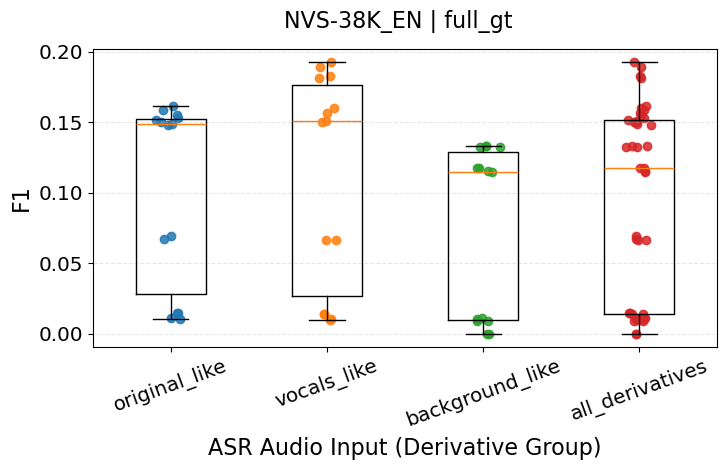

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_audio_derivatives_boxplot_NVS-38K_EN_full_gt.png


In [21]:
from evaluation.rq_plots import plot_rq2b_boxplots_by_setting

rq2b_boxplots_full = plot_rq2b_boxplots_by_setting(
    rq2a_single_all,
    mode="full_gt",
    score_col="macro_mean_f1",
    top_k=None,
    setting_order=setting_order,
)

for setting, fig in rq2b_boxplots_full.items():
    plt.show(fig)

    out_path = rq_results_dir / f"rq2_sensitivity_configuration_audio_derivatives_boxplot_{setting.replace(' | ', '_')}.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(out_path)

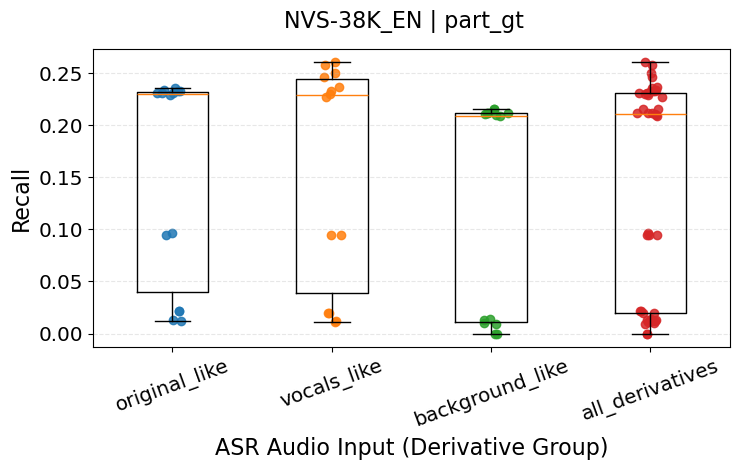

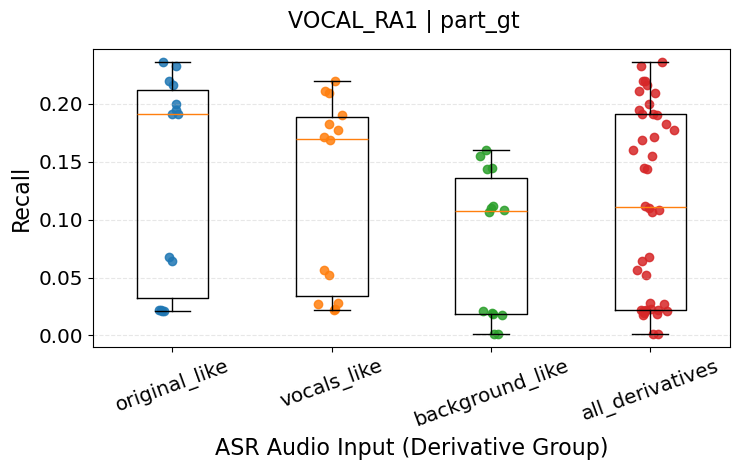

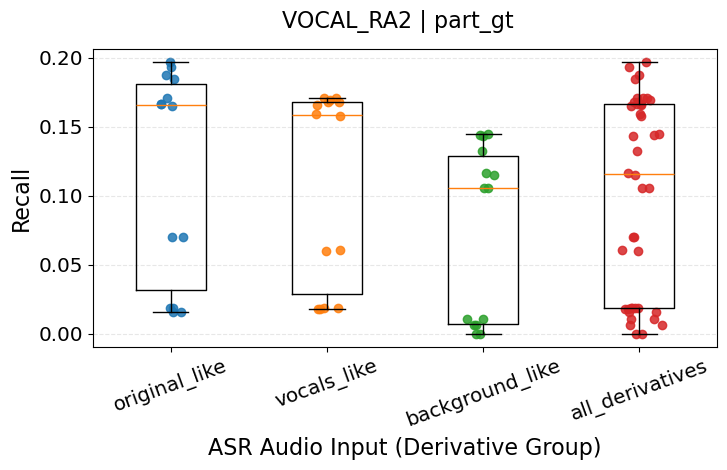

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_audio_derivatives_boxplot_NVS-38K_EN_part_gt.png
/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_audio_derivatives_boxplot_VOCAL_RA1_part_gt.png
/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_audio_derivatives_boxplot_VOCAL_RA2_part_gt.png


In [22]:
rq2b_boxplots_part = plot_rq2b_boxplots_by_setting(
    rq2a_single_all,
    mode="part_gt",
    score_col="macro_mean_recall",
    top_k=None,
    setting_order=setting_order,
)

for setting, fig in rq2b_boxplots_part.items():
    plt.show(fig)

    out_path = rq_results_dir / f"rq2_sensitivity_configuration_audio_derivatives_boxplot_{setting.replace(' | ', '_')}.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(out_path)

## Audio Derivative Boxplot (not grouped)

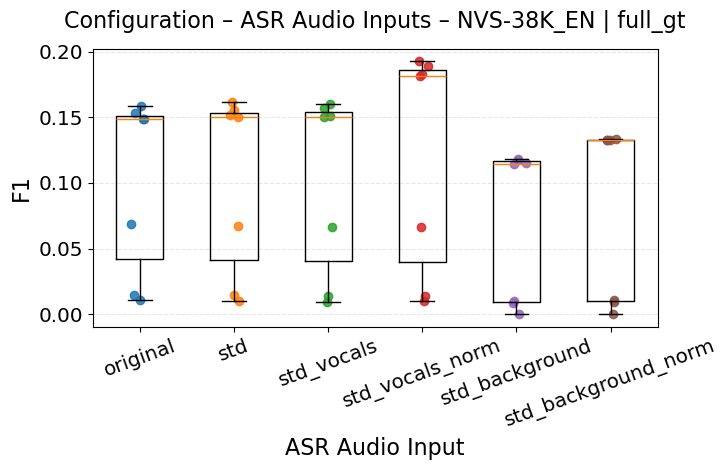

In [23]:
from evaluation.rq_plots import plot_rq2b_boxplots_by_asr_audio_input_by_setting
rq2b_boxplots_asr_full = plot_rq2b_boxplots_by_asr_audio_input_by_setting(
    rq2a_single_all,
    mode="full_gt",
    score_col="macro_mean_f1",
    top_k=None,
    setting_order=setting_order,
)

for setting, fig in rq2b_boxplots_asr_full.items():
    plt.show(fig)

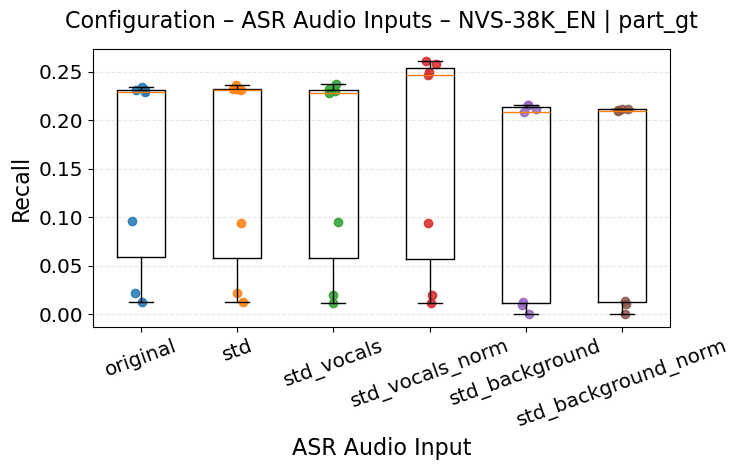

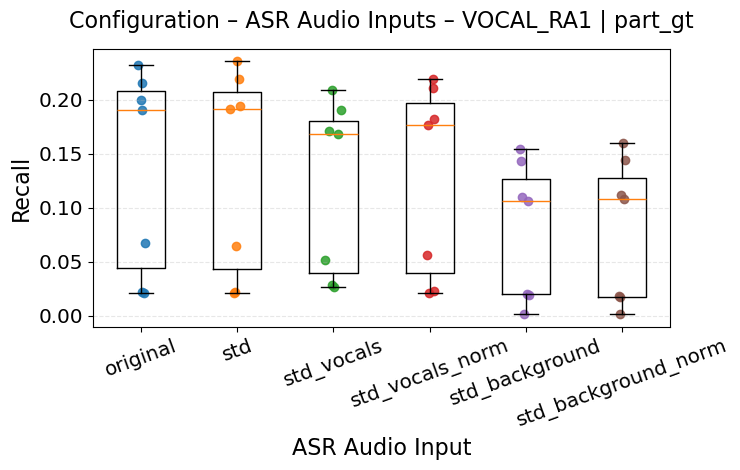

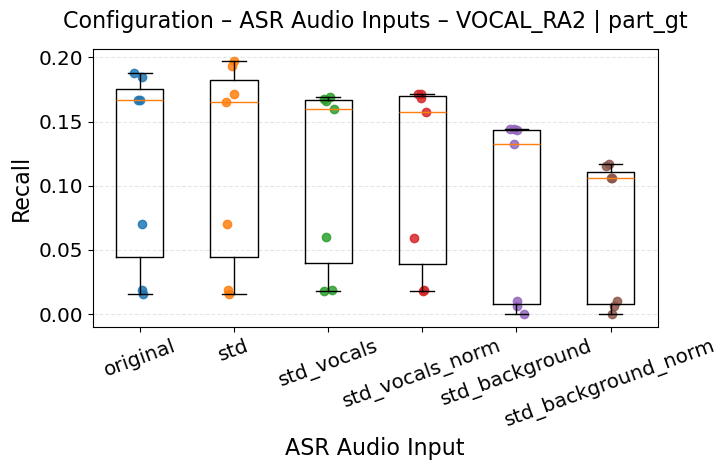

In [24]:
rq2b_boxplots_asr_part = plot_rq2b_boxplots_by_asr_audio_input_by_setting(
    rq2a_single_all,
    mode="part_gt",
    score_col="macro_mean_recall",
    top_k=None,
    setting_order=setting_order,
)

for setting, fig in rq2b_boxplots_asr_part.items():
    plt.show(fig)

## RQ2b Inspection of top 2

In [25]:
from evaluation.analysis_tables import inspect_top_n_rq2a_configs_by_group

df_top2_derivatives_full = inspect_top_n_rq2a_configs_by_group(
    rq2a_single_all,
    mode="full_gt",
    group_by="audio_derivative_group",
    top_n=2,
    setting_order=setting_order,
)
display(df_top2_derivatives_full)

df_top2_derivatives_part = inspect_top_n_rq2a_configs_by_group(
    rq2a_single_all,
    mode="part_gt",
    group_by="audio_derivative_group",
    top_n=2,
    setting_order=setting_order,
)
display(df_top2_derivatives_part)

,setting,audio_derivative_group,combo_key,vad_mask,asr_audio_in,macro_mean_f1,macro_mean_recall,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp,macro_mean_insertion_rate,rank_within_run
0,NVS-38K_EN | full_gt,background_like,std_vocals_vad_std_background_norm_asr_nlp_nvv,std_vocals,std_background_norm,0.133125,0.211935,0.185948,0.185948,1.767429,17
1,NVS-38K_EN | full_gt,background_like,std_vocals_norm_vad_std_background_norm_asr_nl...,std_vocals_norm,std_background_norm,0.133016,0.210820,0.185117,0.185117,1.761852,18
2,NVS-38K_EN | full_gt,original_like,original_vad_std_asr_nlp_nvv,original,std,0.161367,0.232571,0.204774,0.204774,1.531511,5
3,NVS-38K_EN | full_gt,original_like,original_vad_original_asr_nlp_nvv,original,original,0.158532,0.230898,0.203614,0.203614,1.520915,7
4,NVS-38K_EN | full_gt,vocals_like,std_vocals_vad_std_vocals_norm_asr_nlp_nvv,std_vocals,std_vocals_norm,0.192599,0.260457,0.227950,0.227950,1.484105,1
5,NVS-38K_EN | full_gt,vocals_like,std_vocals_norm_vad_std_vocals_norm_asr_nlp_nvv,std_vocals_norm,std_vocals_norm,0.189115,0.258226,0.226216,0.226216,1.495259,2


,setting,audio_derivative_group,combo_key,vad_mask,asr_audio_in,macro_mean_recall,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp,macro_mean_insertion_rate,rank_within_run
0,NVS-38K_EN | part_gt,background_like,std_vocals_vad_std_background_asr_nlp_nvv,std_vocals,std_background,0.215839,0.189689,0.189689,2.309537,17
1,NVS-38K_EN | part_gt,background_like,std_vocals_norm_vad_std_background_asr_nlp_nvv,std_vocals_norm,std_background,0.215282,0.189520,0.189520,2.308422,18
2,NVS-38K_EN | part_gt,original_like,std_vocals_vad_std_asr_nlp_nvv,std_vocals,std,0.235917,0.210177,0.210177,1.524261,6
3,NVS-38K_EN | part_gt,original_like,std_vocals_vad_original_asr_nlp_nvv,std_vocals,original,0.233687,0.208438,0.208438,1.511991,7
4,NVS-38K_EN | part_gt,vocals_like,std_vocals_vad_std_vocals_norm_asr_nlp_nvv,std_vocals,std_vocals_norm,0.260457,0.227950,0.227950,1.484105,1
5,NVS-38K_EN | part_gt,vocals_like,std_vocals_norm_vad_std_vocals_norm_asr_nlp_nvv,std_vocals_norm,std_vocals_norm,0.258226,0.226216,0.226216,1.495259,2
6,VOCAL_RA1 | part_gt,background_like,std_vocals_norm_vad_std_background_norm_asr_nl...,std_vocals_norm,std_background_norm,0.159783,0.139697,0.313792,2.628160,17
7,VOCAL_RA1 | part_gt,background_like,std_vocals_norm_vad_std_background_asr_nlp_nvv,std_vocals_norm,std_background,0.154889,0.136033,0.297520,2.676850,18
8,VOCAL_RA1 | part_gt,original_like,std_vocals_norm_vad_std_asr_nlp_nvv,std_vocals_norm,std,0.235670,0.206734,0.400543,1.758203,1
9,VOCAL_RA1 | part_gt,original_like,std_vocals_norm_vad_original_asr_nlp_nvv,std_vocals_norm,original,0.232170,0.203808,0.394814,1.693515,2


## Configuration Heatmaps ASR Audio in x VAD mask

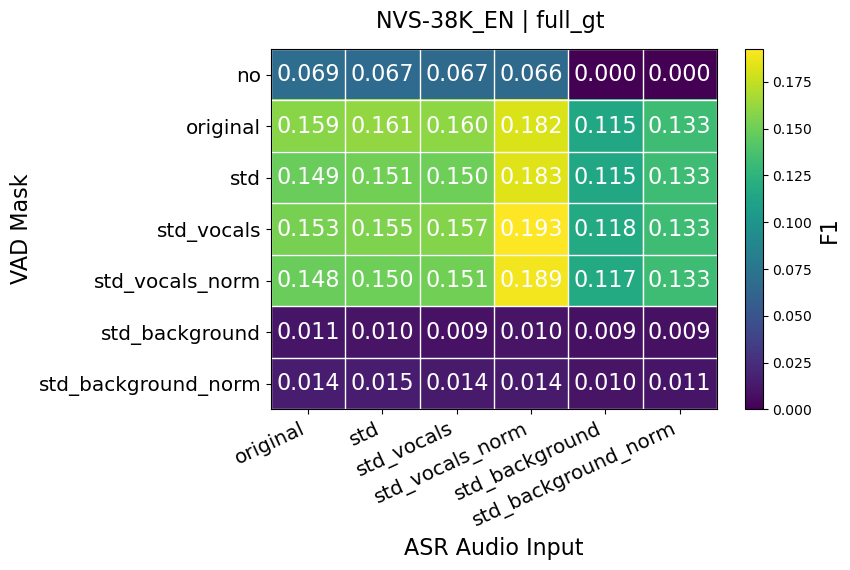

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_audio_derivatives_heatmap_NVS-38K_EN_full_gt_macro_mean_f1.png


In [26]:
from evaluation.rq_plots import plot_rq2b_heatmaps_by_setting

rq2b_heatmaps_full = plot_rq2b_heatmaps_by_setting(
    rq2a_single_all,
    mode="full_gt",
    score_col="macro_mean_f1",
    setting_order=setting_order,
    agg="mean",
    annot=True,
    annot_fontsize=16,
    figsize=(8.5, 5.8),
    cmap="viridis",
)

for setting, fig in rq2b_heatmaps_full.items():
    plt.show(fig)

    out_path = rq_results_dir / f"rq2_sensitivity_configuration_audio_derivatives_heatmap_{setting.replace(' | ', '_')}_macro_mean_f1.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(out_path)

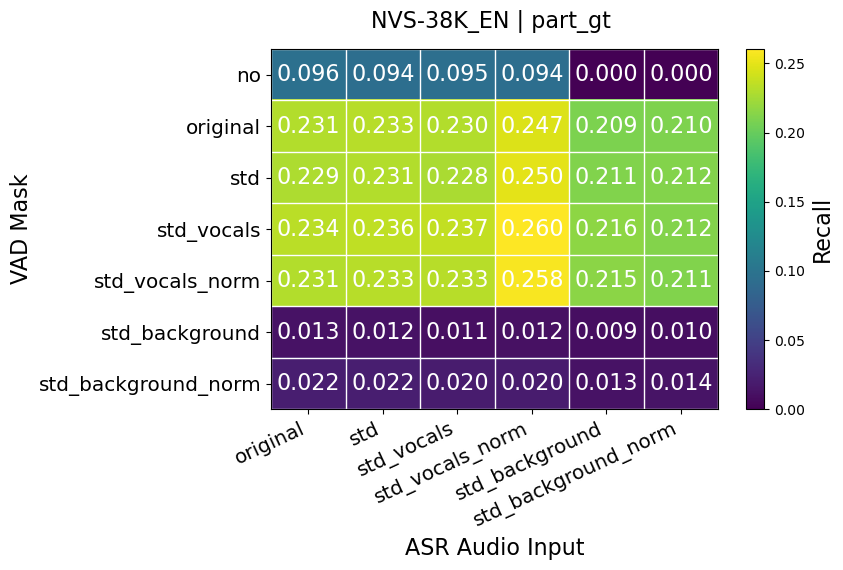

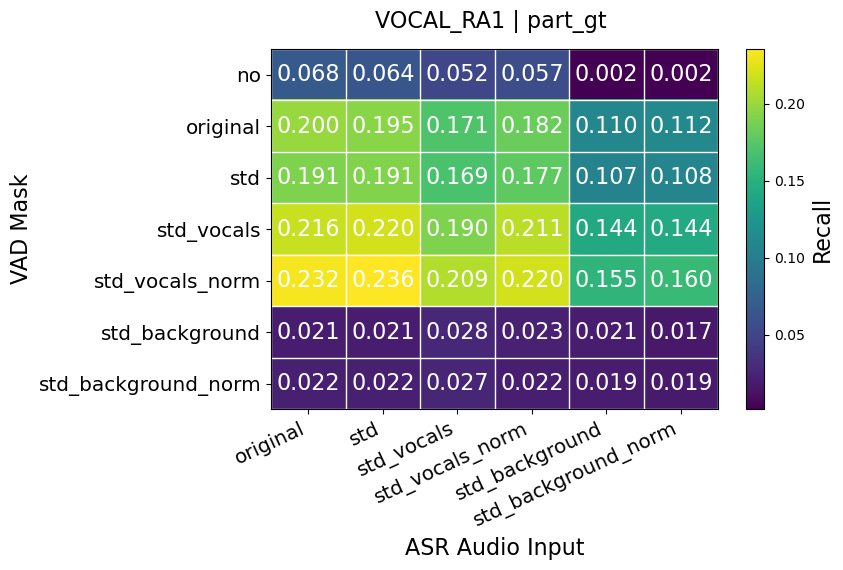

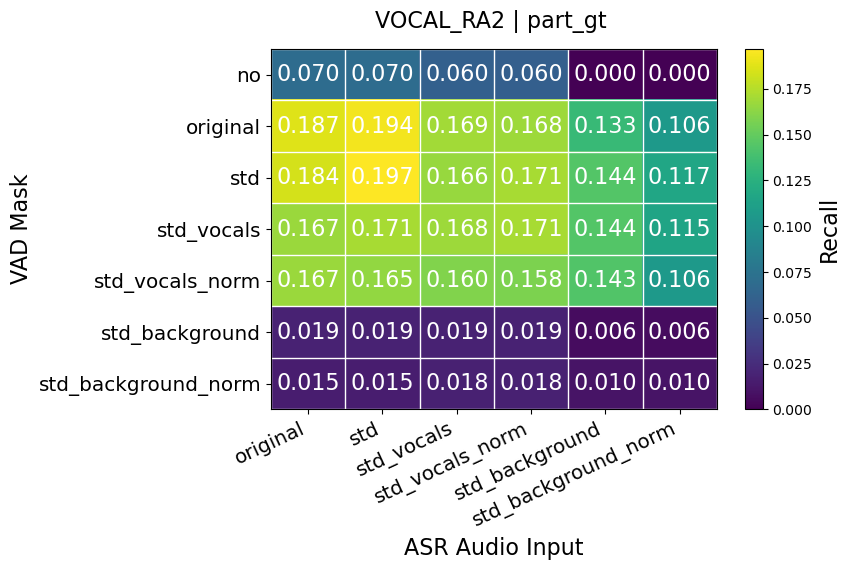

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_audio_derivatives_heatmap_NVS-38K_EN_part_gt_macro_mean_recall.png
/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_audio_derivatives_heatmap_VOCAL_RA1_part_gt_macro_mean_recall.png
/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_audio_derivatives_heatmap_VOCAL_RA2_part_gt_macro_mean_recall.png


In [27]:
rq2b_heatmaps_part = plot_rq2b_heatmaps_by_setting(
    rq2a_single_all,
    mode="part_gt",
    score_col="macro_mean_recall",
    setting_order=setting_order,
    agg="mean",
    annot=True,
    annot_fontsize=16,
    figsize=(8.5, 5.8),
    cmap="viridis",
)

for setting, fig in rq2b_heatmaps_part.items():
    plt.show(fig)

    out_path = rq_results_dir / f"rq2_sensitivity_configuration_audio_derivatives_heatmap_{setting.replace(' | ', '_')}_macro_mean_recall.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(out_path)

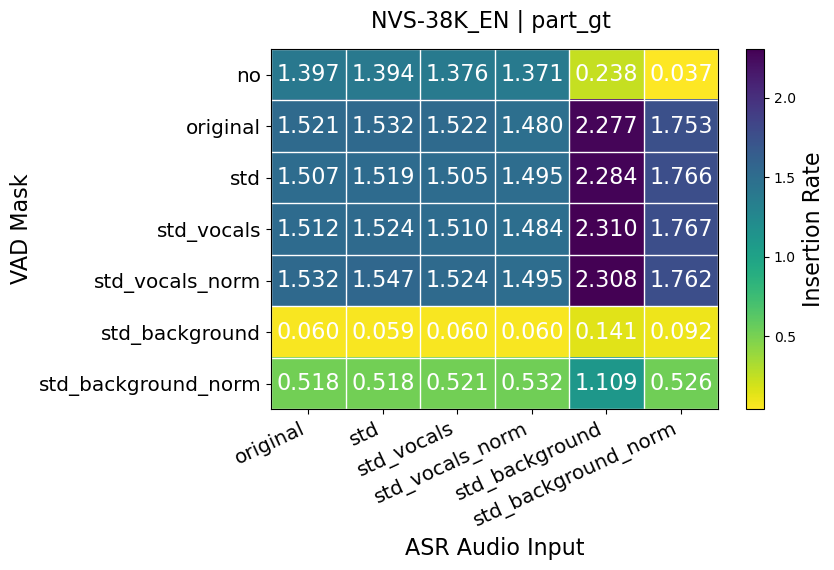

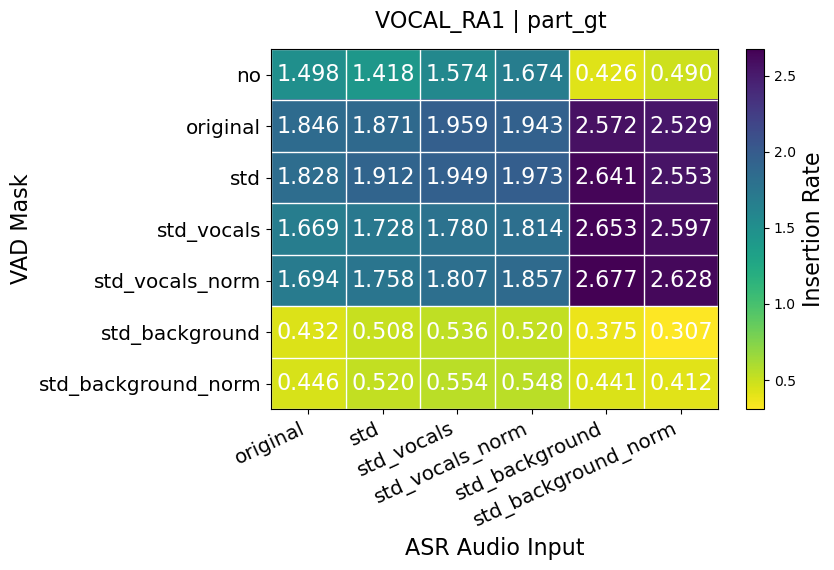

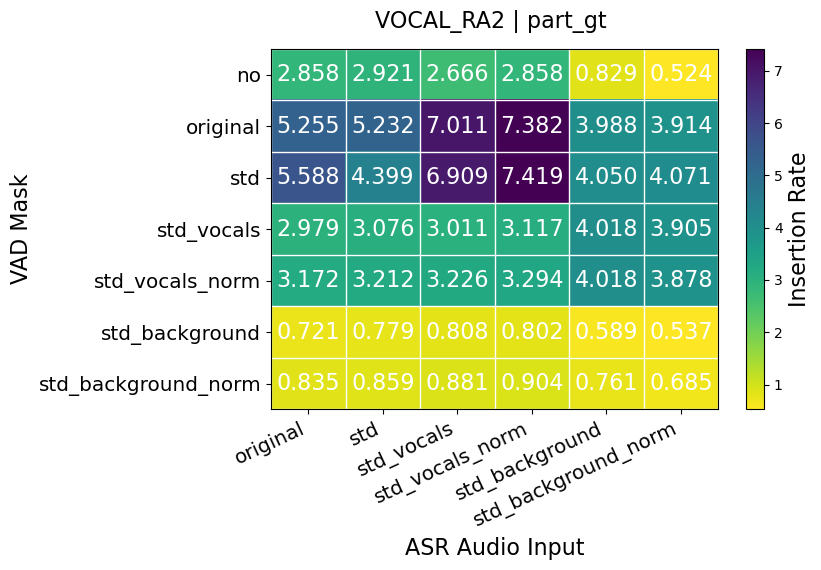

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_audio_derivatives_heatmap_NVS-38K_EN_part_gt_macro_mean_insertion_rate.png
/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_audio_derivatives_heatmap_VOCAL_RA1_part_gt_macro_mean_insertion_rate.png
/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq2_sensitivity_configuration_audio_derivatives_heatmap_VOCAL_RA2_part_gt_macro_mean_insertion_rate.png


In [28]:
rq2b_heatmaps_part = plot_rq2b_heatmaps_by_setting(
    rq2a_single_all,
    mode="part_gt",
    score_col="macro_mean_insertion_rate",
    setting_order=setting_order,
    agg="mean",
    annot=True,
    annot_fontsize=16,
    figsize=(8.5, 5.8),
    cmap="viridis_r",
)

for setting, fig in rq2b_heatmaps_part.items():
    plt.show(fig)

    out_path = rq_results_dir / f"rq2_sensitivity_configuration_audio_derivatives_heatmap_{setting.replace(' | ', '_')}_macro_mean_insertion_rate.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(out_path)

## Configuration VAD Mask Inspection

In [29]:
from evaluation.analysis_tables import build_rq2b_vad_mask_tables

rq2b_vad_tables = build_rq2b_vad_mask_tables(
    rq2a_single_all,
    setting_order=setting_order,
)

display(rq2b_vad_tables["full_gt"])
display(rq2b_vad_tables["part_gt"])

,Setting,VAD Mask,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN | full_gt,no,0.044861,0.063302,0.053828,0.053828,0.968953
1,NVS-38K_EN | full_gt,original,0.151491,0.226436,0.199012,0.199012,1.680889
2,NVS-38K_EN | full_gt,std,0.146982,0.226715,0.200337,0.200337,1.679494
3,NVS-38K_EN | full_gt,std_background,0.009754,0.011247,0.010067,0.010067,0.078732
4,NVS-38K_EN | full_gt,std_background_norm,0.012974,0.018405,0.016491,0.016491,0.620468
5,NVS-38K_EN | full_gt,std_vocals,0.151469,0.232478,0.205471,0.205471,1.684514
6,NVS-38K_EN | full_gt,std_vocals_norm,0.148227,0.230061,0.203560,0.203560,1.694553


,Setting,VAD Mask,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN | part_gt,no,0.063302,0.053828,0.053828,0.968953
1,NVS-38K_EN | part_gt,original,0.226436,0.199012,0.199012,1.680889
2,NVS-38K_EN | part_gt,std,0.226715,0.200337,0.200337,1.679494
3,NVS-38K_EN | part_gt,std_background,0.011247,0.010067,0.010067,0.078732
4,NVS-38K_EN | part_gt,std_background_norm,0.018405,0.016491,0.016491,0.620468
5,NVS-38K_EN | part_gt,std_vocals,0.232478,0.205471,0.205471,1.684514
6,NVS-38K_EN | part_gt,std_vocals_norm,0.230061,0.203560,0.203560,1.694553
7,VOCAL_RA1 | part_gt,no,0.040623,0.034930,0.085893,1.179916
8,VOCAL_RA1 | part_gt,original,0.161528,0.143790,0.304820,2.119849
9,VOCAL_RA1 | part_gt,std,0.157225,0.139677,0.289121,2.142676


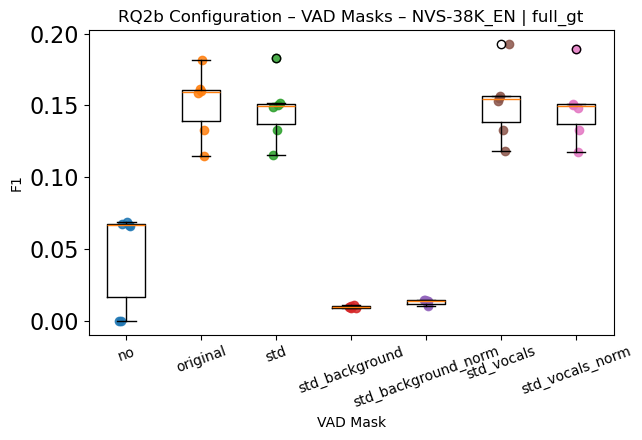

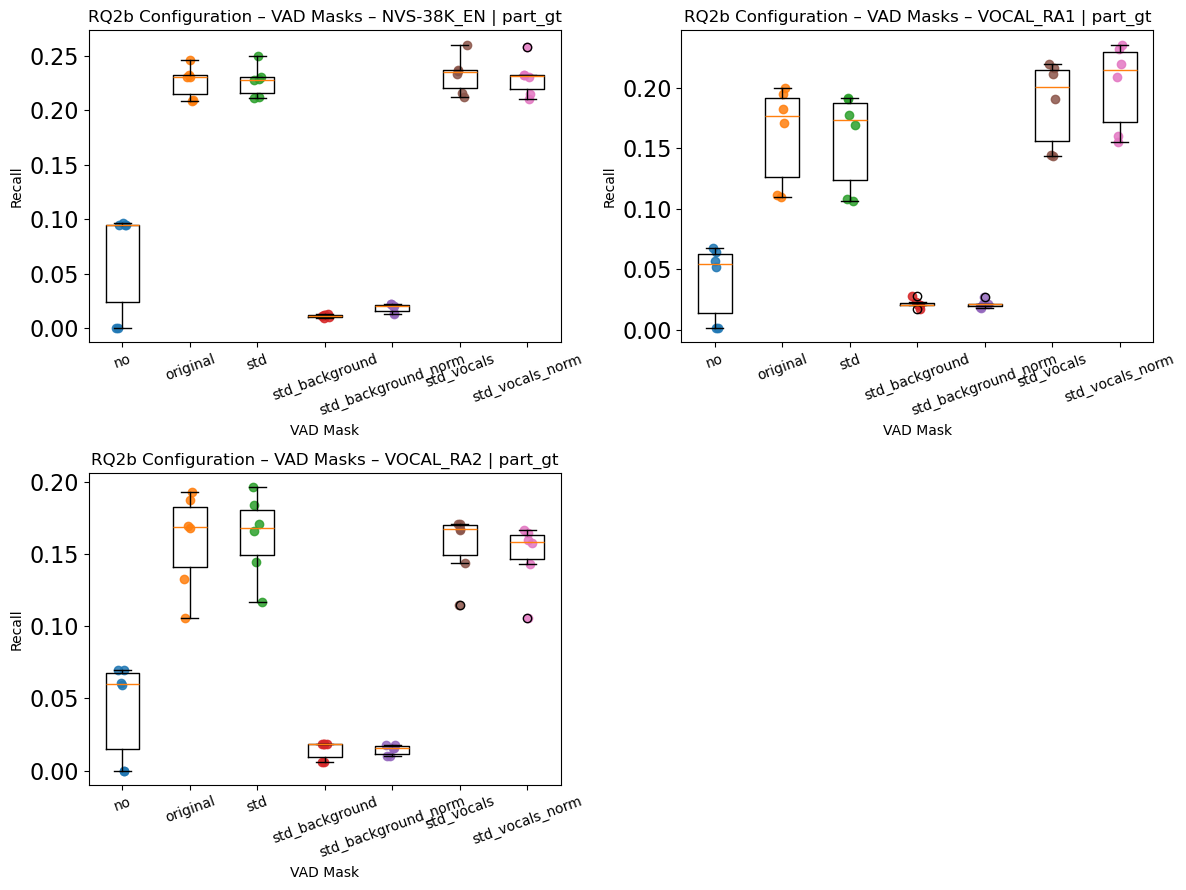

In [30]:
from evaluation.rq_plots import plot_rq2b_vad_mask_boxplot_with_points

fig = plot_rq2b_vad_mask_boxplot_with_points(
    rq2a_single_all,
    mode="full_gt",
    score_col="macro_mean_f1",
    top_k=None,
    setting_order=setting_order,
)
plt.show()

fig = plot_rq2b_vad_mask_boxplot_with_points(
    rq2a_single_all,
    mode="part_gt",
    score_col="macro_mean_recall",
    top_k=None,
    setting_order=setting_order,
)
plt.show()

In [31]:
df_top2_vad_full = inspect_top_n_rq2a_configs_by_group(
    rq2a_single_all,
    mode="full_gt",
    group_by="vad_mask",
    top_n=2,
    setting_order=setting_order,
)
display(df_top2_vad_full)

df_top2_vad_part = inspect_top_n_rq2a_configs_by_group(
    rq2a_single_all,
    mode="part_gt",
    group_by="vad_mask",
    top_n=2,
    setting_order=setting_order,
)
display(df_top2_vad_part)

,setting,vad_mask,combo_key,vad_mask,asr_audio_in,macro_mean_f1,macro_mean_recall,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp,macro_mean_insertion_rate,rank_within_run
0,NVS-38K_EN | full_gt,no,no_vad_original_asr_nlp_nvv,no,original,0.068944,0.096486,0.082422,0.082422,1.396542,25
1,NVS-38K_EN | full_gt,no,no_vad_std_asr_nlp_nvv,no,std,0.067394,0.094255,0.080437,0.080437,1.394311,26
2,NVS-38K_EN | full_gt,original,original_vad_std_vocals_norm_asr_nlp_nvv,original,std_vocals_norm,0.181569,0.246514,0.216277,0.216277,1.480201,4
3,NVS-38K_EN | full_gt,original,original_vad_std_asr_nlp_nvv,original,std,0.161367,0.232571,0.204774,0.204774,1.531511,5
4,NVS-38K_EN | full_gt,std,std_vad_std_vocals_norm_asr_nlp_nvv,std,std_vocals_norm,0.183257,0.249861,0.218978,0.218978,1.494702,3
5,NVS-38K_EN | full_gt,std,std_vad_std_asr_nlp_nvv,std,std,0.151447,0.230898,0.205536,0.205536,1.519241,11
6,NVS-38K_EN | full_gt,std_background,std_background_vad_original_asr_nlp_nvv,std_background,original,0.010913,0.012828,0.011515,0.011515,0.060234,34
7,NVS-38K_EN | full_gt,std_background,std_background_vad_std_asr_nlp_nvv,std_background,std,0.010355,0.012270,0.011013,0.011013,0.059119,35
8,NVS-38K_EN | full_gt,std_background_norm,std_background_norm_vad_std_asr_nlp_nvv,std_background_norm,std,0.014710,0.021751,0.019424,0.019424,0.517568,29
9,NVS-38K_EN | full_gt,std_background_norm,std_background_norm_vad_original_asr_nlp_nvv,std_background_norm,original,0.014432,0.021751,0.019393,0.019393,0.517568,30


,setting,vad_mask,combo_key,vad_mask,asr_audio_in,macro_mean_recall,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp,macro_mean_insertion_rate,rank_within_run
0,NVS-38K_EN | part_gt,no,no_vad_original_asr_nlp_nvv,no,original,0.096486,0.082422,0.082422,1.396542,25
1,NVS-38K_EN | part_gt,no,no_vad_std_vocals_asr_nlp_nvv,no,std_vocals,0.094813,0.080236,0.080236,1.376464,26
2,NVS-38K_EN | part_gt,original,original_vad_std_vocals_norm_asr_nlp_nvv,original,std_vocals_norm,0.246514,0.216277,0.216277,1.480201,4
3,NVS-38K_EN | part_gt,original,original_vad_std_asr_nlp_nvv,original,std,0.232571,0.204774,0.204774,1.531511,10
4,NVS-38K_EN | part_gt,std,std_vad_std_vocals_norm_asr_nlp_nvv,std,std_vocals_norm,0.249861,0.218978,0.218978,1.494702,3
5,NVS-38K_EN | part_gt,std,std_vad_std_asr_nlp_nvv,std,std,0.230898,0.205536,0.205536,1.519241,12
6,NVS-38K_EN | part_gt,std_background,std_background_vad_original_asr_nlp_nvv,std_background,original,0.012828,0.011515,0.011515,0.060234,35
7,NVS-38K_EN | part_gt,std_background,std_background_vad_std_asr_nlp_nvv,std_background,std,0.012270,0.011013,0.011013,0.059119,36
8,NVS-38K_EN | part_gt,std_background_norm,std_background_norm_vad_std_asr_nlp_nvv,std_background_norm,std,0.021751,0.019424,0.019424,0.517568,29
9,NVS-38K_EN | part_gt,std_background_norm,std_background_norm_vad_original_asr_nlp_nvv,std_background_norm,original,0.021751,0.019393,0.019393,0.517568,30


## RQ3 NVV Coverage

In [32]:
## RQ3 NVV Coverage

from evaluation.analysis_tables import (
    build_rq3_full_gt_label_tables,
    build_rq3_part_gt_event_tables,
    build_rq3_global_tables,
)

rq3_label_all = pd.concat(
    [
        bundle["results"]["rq3_label"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq3_global_all = pd.concat(
    [
        bundle["results"]["rq3_global"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq3_full_gt_label_tables = build_rq3_full_gt_label_tables(rq3_label_all)
rq3_part_gt_event_tables = build_rq3_part_gt_event_tables(rq3_label_all)
#rq3_global_tables = build_rq3_global_tables(rq3_global_all)



## RQ3 Global Metrics Tables - Full-GT and Part-GT

In [33]:
#from evaluation.analysis_tables import format_df_3decimals
#display(format_df_3decimals(rq3_global_tables["full_gt"]))
#display(format_df_3decimals(rq3_global_tables["part_gt"]))


In [34]:
from evaluation.analysis_tables import build_rq3_global_thesis_table

rq3_global_thesis_table = build_rq3_global_thesis_table(rq3_global_all)
rq3_global_thesis_table.style.set_properties(**{"text-align": "center"}).hide(axis="index")

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/evaluation/analysis_tables.py:2131: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_out = pd.concat([df_full, df_part], ignore_index=True)


Setting,N_GT,TP,FN,Insertions,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
NVS-38K_EN | full_gt,1793,485,1308,2721,0.194,0.270,0.237,0.876,1.518
VOCAL_RA1 | part_gt,501,124,377,1323,,0.248,0.217,0.878,2.641
VOCAL_RA2 | part_gt,332,76,256,1554,,0.229,0.197,0.860,4.681


In [35]:
# save RQ3 appendix table for Word/Excel
rq3_global_path = rq_results_dir / "rq3_nvv_coverage_global_table.xlsx"


with pd.ExcelWriter(rq3_global_path, engine="openpyxl") as writer:
    rq3_global_thesis_table.to_excel(writer, sheet_name="Global NVV Coverage", merge_cells=True)

print(rq3_global_path)

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq3_nvv_coverage_global_table.xlsx


## RQ3 Label Coverage (Full-GT) Table and Plot

In [36]:
print("RQ3 Event Tables (Full-GT):")
for setting_name, df_table in rq3_full_gt_label_tables.items():
    print(f"\n=== {setting_name} ===")
    display(df_table.round(3))

RQ3 Event Tables (Full-GT):

=== NVS-38K_EN | full_gt ===


,Setting,Label,n_gt_events,tp,fn,Recall,EOS Recall,Mean EOS TP,Mean Overlap (s)
0,NVS-38K_EN | full_gt,sigh,307,118,189,0.384,0.350,0.911,0.644
1,NVS-38K_EN | full_gt,gasp,34,13,21,0.382,0.349,0.913,0.548
2,NVS-38K_EN | full_gt,throatclearing,486,154,332,0.317,0.266,0.838,0.371
3,NVS-38K_EN | full_gt,yawn,17,5,12,0.294,0.281,0.955,0.882
4,NVS-38K_EN | full_gt,sniff,117,27,90,0.231,0.204,0.885,0.378
5,NVS-38K_EN | full_gt,coughing,400,89,311,0.222,0.192,0.863,0.407
6,NVS-38K_EN | full_gt,crying,37,8,29,0.216,0.191,0.885,0.851
7,NVS-38K_EN | full_gt,breath,74,16,58,0.216,0.183,0.849,0.527
8,NVS-38K_EN | full_gt,laughing,309,53,256,0.172,0.157,0.916,0.947
9,NVS-38K_EN | full_gt,snore,12,2,10,0.167,0.160,0.958,0.842


In [37]:
rq3_label_path = rq_results_dir / "rq3_nvv_coverage_label_counts_appendix_table.xlsx"

df_label = rq3_full_gt_label_tables["NVS-38K_EN | full_gt"].copy()
from evaluation.analysis_tables import format_df_3decimals
df_label = format_df_3decimals(df_label)

with pd.ExcelWriter(rq3_label_path, engine="openpyxl") as writer:
    df_label.to_excel(writer, sheet_name="Label Counts", index=False)

print(rq3_label_path)

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq3_nvv_coverage_label_counts_appendix_table.xlsx


/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/evaluation/rq_plots.py:1101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=font_size * 0.9)


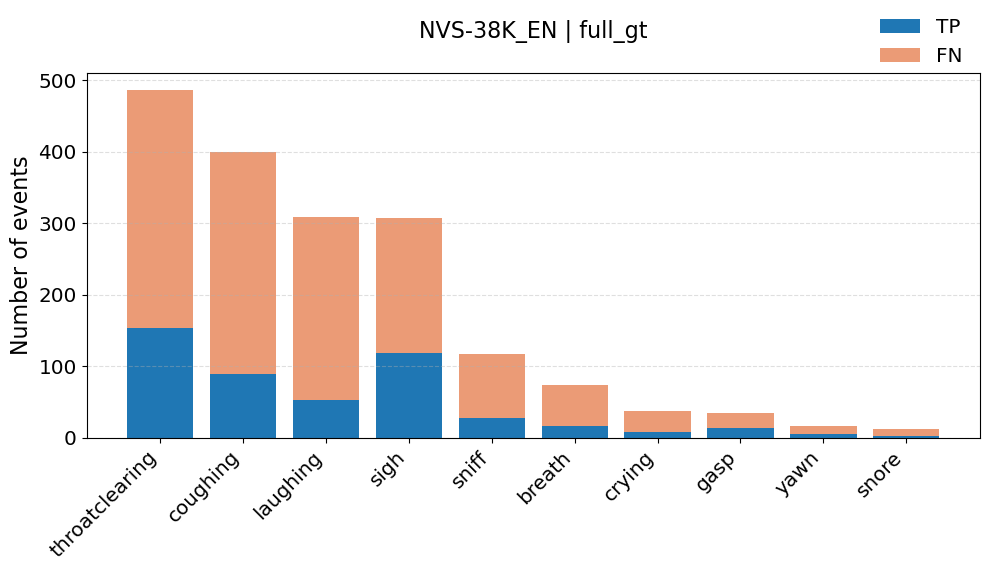

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq3_nvv_coverage_label_counts.png


In [38]:
from evaluation.rq_plots import plot_rq3_label_coverage

fig = plot_rq3_label_coverage(
    rq3_full_gt_label_tables["NVS-38K_EN | full_gt"],
    setting=None,
)
plt.show()

fig_path = rq_results_dir / "rq3_nvv_coverage_label_counts.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(fig_path)


## RQ3 Label quality (full-GT)

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/evaluation/rq_plots.py:1184: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks().astype(float).round(2), fontsize=font_size * 0.9)


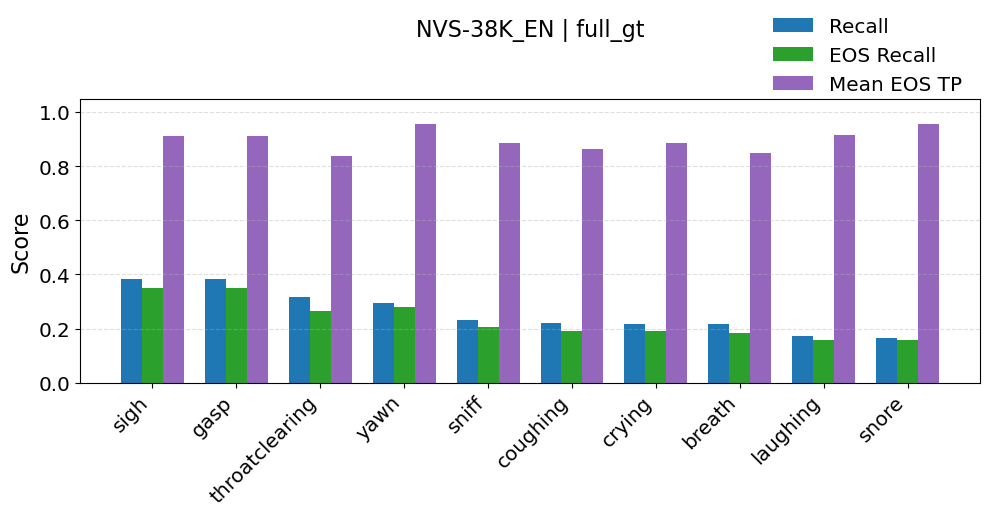

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq3_nvv_coverage_label_quality.png


In [39]:
from evaluation.rq_plots import plot_rq3_label_quality

fig = plot_rq3_label_quality(
    rq3_full_gt_label_tables["NVS-38K_EN | full_gt"]
)
plt.show()

fig_path = rq_results_dir / "rq3_nvv_coverage_label_quality.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(fig_path)

## RQ3 Global Recall Comparison (Full-GT - Part-GT)

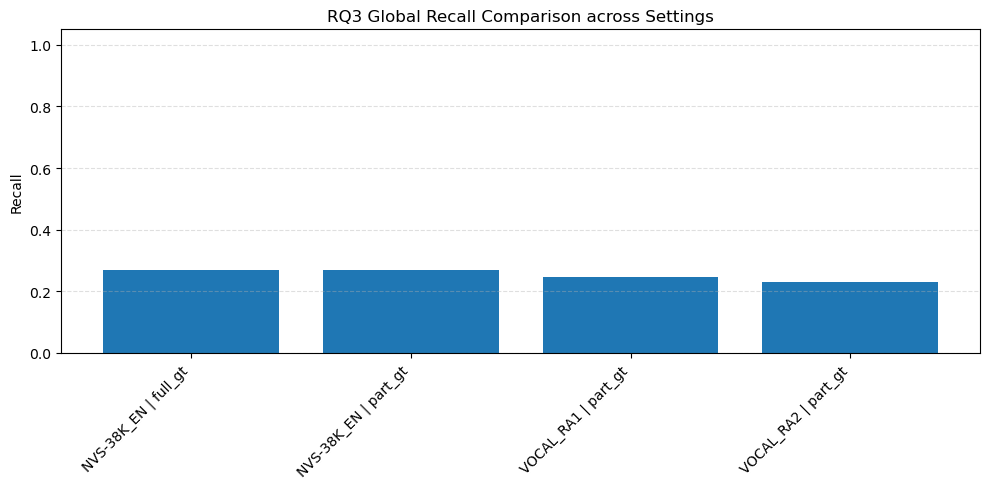

In [40]:
from evaluation.rq_plots import plot_rq3_global_recall_comparison

fig = plot_rq3_global_recall_comparison(
    rq3_global_all,
    setting_order=setting_order,
)
plt.show()

## RQ3 Event Samples (Part-GT) Tables

In [41]:
## RQ3 Event Samples (Part-GT) Tables
print("RQ3 Event Tables (Part-GT):")
for setting_name, df_table in rq3_part_gt_event_tables.items():
    print(f"\n=== {setting_name} ===")
    display(df_table)

RQ3 Event Tables (Part-GT):

=== NVS-38K_EN | part_gt ===


,Setting,Audio ID,GT Event ID,GT Label,Cand Event ID,Cand Label,Status,EOS,Overlap (s)
0,NVS-38K_EN | part_gt,nvs38k_00007,NVS_EN_000001,sigh,1,non_word (nlp): [UH],Hit,0.877,0.800
1,NVS-38K_EN | part_gt,nvs38k_00020,NVS_EN_000002,throatclearing,1,filler (nlp): Hmm.,Hit,0.880,0.627
2,NVS-38K_EN | part_gt,nvs38k_00130,NVS_EN_000008,sigh,1,filler (nlp): Ah.,Hit,0.870,0.420
3,NVS-38K_EN | part_gt,nvs38k_00174,NVS_EN_000010,throatclearing,1,filler (nlp): Huh.,Hit,0.872,0.316
4,NVS-38K_EN | part_gt,nvs38k_00223,NVS_EN_000013,laughing,1,nvv (vad_gap),Hit,0.948,1.067
...,...,...,...,...,...,...,...,...,...
4509,NVS-38K_EN | part_gt,nvs38k_38559,NaN,NaN,1,filler (nlp): Like,Insertion,NaN,NaN
4510,NVS-38K_EN | part_gt,nvs38k_38615,NaN,NaN,1,filler (nlp): Huh?,Insertion,NaN,NaN
4511,NVS-38K_EN | part_gt,nvs38k_38615,NaN,NaN,2,non_word (nlp): [UH],Insertion,NaN,NaN
4512,NVS-38K_EN | part_gt,nvs38k_38616,NaN,NaN,1,filler (nlp): Oh.,Insertion,NaN,NaN



=== VOCAL_RA1 | part_gt ===


,Setting,Audio ID,GT Event ID,GT Label,Cand Event ID,Cand Label,Status,EOS,Overlap (s)
0,VOCAL_RA1 | part_gt,-RoRyAeTlLY,a_RA1_721_05,um,6,non_word (nlp): [UM],Hit,0.885,0.580
1,VOCAL_RA1 | part_gt,-RoRyAeTlLY,a_RA1_721_06,um,8,non_word (nlp): [UM],Hit,0.855,0.543
2,VOCAL_RA1 | part_gt,-RoRyAeTlLY,a_RA1_721_08,uh,22,non_word (nlp): [UH],Hit,0.813,0.545
3,VOCAL_RA1 | part_gt,0O0QQkVKuFw,a_RA1_741_02,sigh,4,non_word (nlp): [UH],Hit,0.764,0.210
4,VOCAL_RA1 | part_gt,0O0QQkVKuFw,a_RA1_741_03,hey yell,8,"filler (nlp): Hey,",Hit,0.788,0.390
...,...,...,...,...,...,...,...,...,...
1819,VOCAL_RA1 | part_gt,z2BtmcDBC5s,NaN,NaN,6,"filler (nlp): Well,",Insertion,NaN,NaN
1820,VOCAL_RA1 | part_gt,zEsDardJXjg,NaN,NaN,1,filler (nlp): Okay.,Insertion,NaN,NaN
1821,VOCAL_RA1 | part_gt,zEsDardJXjg,NaN,NaN,2,filler (nlp): Yeah.,Insertion,NaN,NaN
1822,VOCAL_RA1 | part_gt,zEsDardJXjg,NaN,NaN,3,filler (nlp): Hmm.,Insertion,NaN,NaN



=== VOCAL_RA2 | part_gt ===


,Setting,Audio ID,GT Event ID,GT Label,Cand Event ID,Cand Label,Status,EOS,Overlap (s)
0,VOCAL_RA2 | part_gt,0CBI5294D10,a_RA2_028,snoring,2,nvv (vad_gap),Hit,0.955,1.388
1,VOCAL_RA2 | part_gt,0ZDqtg42pxY,a_RA2_032_01,grunting,4,"filler (nlp): oh,",Hit,0.844,0.460
2,VOCAL_RA2 | part_gt,1msGzgrd3Pw,a_RA1_771_01,exhale,1,oov (nlp): Felsen,Hit,0.912,1.163
3,VOCAL_RA2 | part_gt,1nHQZ3goq2o,a_RA2_035_02,ah sound,7,non_word (nlp): [UH],Hit,0.940,0.503
4,VOCAL_RA2 | part_gt,1nHQZ3goq2o,a_RA2_035_03,um sound,8,non_word (nlp): [UM],Hit,0.832,0.570
...,...,...,...,...,...,...,...,...,...
1881,VOCAL_RA2 | part_gt,ydAyvvDQrgY,NaN,NaN,12,nvv (vad_gap),Insertion,NaN,NaN
1882,VOCAL_RA2 | part_gt,ydAyvvDQrgY,NaN,NaN,13,filler (nlp): alright.,Insertion,NaN,NaN
1883,VOCAL_RA2 | part_gt,ydAyvvDQrgY,NaN,NaN,14,filler (nlp): Yeah.,Insertion,NaN,NaN
1884,VOCAL_RA2 | part_gt,ydAyvvDQrgY,NaN,NaN,15,"filler (nlp): Yeah,",Insertion,NaN,NaN


In [42]:
display(rq1_tables["full_gt"].columns)
display(rq2a_single_all.columns)
display(rq3_global_thesis_table.columns)

Index(['Setting', 'System', 'F1', 'Recall', 'EOS Recall', 'Mean EOS TP',
       'Insertion Rate'],
      dtype='object')

Index(['setting', 'dataset_name', 'mode', 'combo_key', 'vad_mask',
       'asr_audio_in', 'n_audio_ids', 'macro_mean_n_gt', 'macro_mean_n_cand',
       'macro_mean_tp', 'macro_mean_fn', 'macro_mean_fp', 'macro_mean_recall',
       'macro_mean_precision', 'macro_mean_f1', 'macro_mean_mean_dice_eos_tp',
       'macro_mean_dice_eos_recall', 'macro_mean_mean_overlap_s_tp',
       'macro_mean_insertion_rate', 'macro_mean_deletion_rate',
       'macro_mean_error_rate', 'rank_within_run'],
      dtype='object')

Index(['Setting', 'N_GT', 'TP', 'FN', 'Insertions', 'F1', 'Recall',
       'EOS Recall', 'Mean EOS TP', 'Insertion Rate'],
      dtype='object')

## NVV Candidate Source Distribution

In [43]:
from evaluation.analysis_tables import build_candidate_source_distribution_table
rq3_candidate_source_dist = build_candidate_source_distribution_table(
    rq3_part_gt_event_tables,
    short_setting_name=True,
)

display(rq3_candidate_source_dist.round(3))

,Dataset,Hit NLP (%),Hit VAD (%),Insertion NLP (%),Insertion VAD (%)
0,NVS-38K_EN,86.186,13.814,93.973,6.027
1,VOCAL_RA1,90.323,9.677,92.517,7.483
2,VOCAL_RA2,89.474,10.526,92.600,7.400


In [44]:
rq3_candidate_source_path = rq_results_dir / "rq3_nvv_coverage_candidate_source_distribution.xlsx"

rq3_candidate_source_dist.round(3).to_excel(
    rq3_candidate_source_path,
    index=False,
)

print(rq3_candidate_source_path)

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq3_nvv_coverage_candidate_source_distribution.xlsx


In [45]:
from evaluation.analysis_tables import build_candidate_label_subtype_table

rq3_candidate_subtypes_by_dataset = build_candidate_label_subtype_table(
    rq3_part_gt_event_tables,
    short_setting_name=True,
)

for dataset, df in rq3_candidate_subtypes_by_dataset.items():
    print(f"\n=== {dataset} ===")
    display(df.round(1))


=== NVS-38K_EN ===


,Dataset,Status,NVV Candidate Type,Count,%
0,NVS-38K_EN,Hit,filler,336,69.3
1,NVS-38K_EN,Hit,non-word,71,14.6
2,NVS-38K_EN,Hit,VAD gap,67,13.8
3,NVS-38K_EN,Hit,oov,11,2.3
4,NVS-38K_EN,Insertion,filler,1681,61.8
5,NVS-38K_EN,Insertion,non-word,723,26.6
6,NVS-38K_EN,Insertion,VAD gap,164,6.0
7,NVS-38K_EN,Insertion,oov,142,5.2
8,NVS-38K_EN,Insertion,unknown,11,0.4



=== VOCAL_RA1 ===


,Dataset,Status,NVV Candidate Type,Count,%
0,VOCAL_RA1,Hit,filler,60,48.4
1,VOCAL_RA1,Hit,non-word,37,29.8
2,VOCAL_RA1,Hit,oov,15,12.1
3,VOCAL_RA1,Hit,VAD gap,12,9.7
4,VOCAL_RA1,Insertion,filler,747,56.5
5,VOCAL_RA1,Insertion,non-word,392,29.6
6,VOCAL_RA1,Insertion,VAD gap,99,7.5
7,VOCAL_RA1,Insertion,oov,77,5.8
8,VOCAL_RA1,Insertion,unknown,8,0.6



=== VOCAL_RA2 ===


,Dataset,Status,NVV Candidate Type,Count,%
0,VOCAL_RA2,Hit,filler,35,46.1
1,VOCAL_RA2,Hit,non-word,24,31.6
2,VOCAL_RA2,Hit,oov,9,11.8
3,VOCAL_RA2,Hit,VAD gap,8,10.5
4,VOCAL_RA2,Insertion,filler,984,63.3
5,VOCAL_RA2,Insertion,non-word,358,23.0
6,VOCAL_RA2,Insertion,VAD gap,115,7.4
7,VOCAL_RA2,Insertion,oov,90,5.8
8,VOCAL_RA2,Insertion,unknown,7,0.5


In [46]:
rq3_candidate_subtype_path = rq_results_dir / "rq3_nvv_coverage_candidate_label_subtype_distribution.xlsx"
with pd.ExcelWriter(rq3_candidate_subtype_path, engine="openpyxl") as writer:
    for dataset, df in rq3_candidate_subtypes_by_dataset.items():
        sheet_name = dataset[:31]
        df_export = df.round(1).copy()
        df_export.to_excel(writer, sheet_name=sheet_name, index=False)
print(rq3_candidate_subtype_path)

/home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/results/rq3_nvv_coverage_candidate_label_subtype_distribution.xlsx


In [47]:
def get_missed_label_counts(rq3_part_gt_event_tables, setting_name, status_filter):
    df = rq3_part_gt_event_tables[setting_name].copy()

    df_miss = df[df["Status"] == status_filter]

    counts = (
        df_miss["GT Label"]
        .astype(str)
        .str.lower()
        .str.strip()
        .value_counts()
        .reset_index()
    )

    counts.columns = ["Label", "Count"]
    counts["%"] = counts["Count"] / counts["Count"].sum() * 100

    return counts

In [48]:

miss_vocal_ra1 = get_missed_label_counts(rq3_part_gt_event_tables, "VOCAL_RA1 | part_gt", status_filter="Miss")
hit_vocal_ra1 = get_missed_label_counts(rq3_part_gt_event_tables, "VOCAL_RA1 | part_gt", status_filter="Hit")
display(miss_vocal_ra1)
display(hit_vocal_ra1)

,Label,Count,%
0,scream,21,5.570292
1,grunt,20,5.305040
2,sneeze,11,2.917772
3,screaming,10,2.652520
4,crying,9,2.387268
...,...,...,...
154,groaning,1,0.265252
155,grunt yell,1,0.265252
156,huh,1,0.265252
157,wohoo,1,0.265252


,Label,Count,%
0,uh,6,4.838710
1,huh sound,6,4.838710
2,grunt,6,4.838710
3,um,5,4.032258
4,burp,5,4.032258
...,...,...,...
66,brrr / lip blow,1,0.806452
67,ohh,1,0.806452
68,gah,1,0.806452
69,throat clear,1,0.806452


In [49]:
def get_all_missed_label_counts(rq3_part_gt_event_tables, status_filter):
    dfs = []

    for setting_name, df in rq3_part_gt_event_tables.items():
        df_local = df.copy()
        df_miss = df_local[df_local["Status"] == status_filter]

        counts = (
            df_miss["GT Label"]
            .astype(str)
            .str.lower()
            .str.strip()
            .value_counts()
            .reset_index()
        )

        counts.columns = ["Label", "Count"]
        counts["%"] = counts["Count"] / counts["Count"].sum() * 100

        counts["Dataset"] = setting_name.split(" | ")[0]

        dfs.append(counts)

    return pd.concat(dfs, ignore_index=True)

In [50]:
miss_all = get_all_missed_label_counts(rq3_part_gt_event_tables, status_filter="Miss")
display(miss_all.head(20))
print(miss_all["Dataset"].value_counts())
#print all VOCAL misses as list with unique labels
VOCAL_unique_misses = miss_all[miss_all["Dataset"].str.startswith("VOCAL")]["Label"].unique()
print(VOCAL_unique_misses)
VOCAL_misses = miss_all[miss_all["Dataset"].str.startswith("VOCAL")]
print(VOCAL_misses["Label"].tolist())
print(f"\nTotal Missed Labels in VOCAL datasets: {len(VOCAL_unique_misses)}")

,Label,Count,%,Dataset
0,throatclearing,332,25.382263,NVS-38K_EN
1,coughing,311,23.776758,NVS-38K_EN
2,laughing,256,19.571865,NVS-38K_EN
3,sigh,189,14.449541,NVS-38K_EN
4,sniff,90,6.880734,NVS-38K_EN
5,breath,58,4.434251,NVS-38K_EN
6,crying,29,2.217125,NVS-38K_EN
7,gasp,21,1.605505,NVS-38K_EN
8,yawn,12,0.917431,NVS-38K_EN
9,snore,10,0.764526,NVS-38K_EN


Dataset
VOCAL_RA1     159
VOCAL_RA2     115
NVS-38K_EN     10
Name: count, dtype: int64
['scream' 'grunt' 'sneeze' 'screaming' 'crying' 'snore' 'laughing' 'burp'
 'yawn' 'laughter' 'oh sound' 'sniff' 'giggle' 'yell' 'ah' 'lip smack'
 'exhale' 'tongue click' 'shh' 'tongue trills' 'cough' 'gasp' 'uhh'
 'sharp inhale' 'woah' 'yelling' 'coo' 'aww sound' 'squealing'
 'argh sound' 'laugh' 'sneezing' 'oh' 'snoring' 'cooing' 'baby noise'
 'groan' 'ow sound' 'sigh' 'ohh' 'brrr' 'cry' 'babble' 'mm sound' 'squeal'
 'blowing air' 'moan' 'scream cry' 'um' 'shushing' 'ah sound' 'slurping'
 'grunt/exhale' 'wow sound' 'woo' 'fart' 'hh' 'inhale' 'coughing'
 'crowd laughter' 'throat clear' 'squeel' 'tsah sound' 'ohh sound'
 'ahh sound' 'pss sound' 'rrrr sound' 'pain vocalization' 'moaning'
 'oh  sound' 'throat clearing' 'baby sound' 'oh oh sound' 'humming'
 'oh yell' 'shhh' 'mmm sound' 'exhale/huh' 'umm' 'low grunt' 'giggling'
 'brrr with lips' 'uhm' 'laugh/cough' 'ah yell' 'moan/exhale' 'oof'
 'grunt/l

In [51]:
hit_all = get_all_missed_label_counts(rq3_part_gt_event_tables, status_filter="Hit")
display(hit_all.head(20))
print(hit_all["Dataset"].value_counts())
VOCAL_unique_hits = hit_all[hit_all["Dataset"].str.startswith("VOCAL")]["Label"].unique()
print(VOCAL_unique_hits)
VOCAL_hits = hit_all[hit_all["Dataset"].str.startswith("VOCAL")]
print(VOCAL_hits["Label"].tolist())
print(f"\nTotal Hit Labels in VOCAL datasets: {len(VOCAL_unique_hits)}")

,Label,Count,%,Dataset
0,throatclearing,154,31.752577,NVS-38K_EN
1,sigh,118,24.329897,NVS-38K_EN
2,coughing,89,18.350515,NVS-38K_EN
3,laughing,53,10.927835,NVS-38K_EN
4,sniff,27,5.567010,NVS-38K_EN
5,breath,16,3.298969,NVS-38K_EN
6,gasp,13,2.680412,NVS-38K_EN
7,crying,8,1.649485,NVS-38K_EN
8,yawn,5,1.030928,NVS-38K_EN
9,snore,2,0.412371,NVS-38K_EN


Dataset
VOCAL_RA1     71
VOCAL_RA2     46
NVS-38K_EN    10
Name: count, dtype: int64
['uh' 'huh sound' 'grunt' 'um' 'burp' 'gasp' 'oh sound' 'oh' 'aww' 'laugh'
 'uhm' 'uh uh' 'mmm sound' 'cough' 'tsah' 'slurp' 'sneeze' 'scream'
 'mm sound' 'uh sound' 'uhh sound' 'moan' 'hh' 'uhh' 'clears throat'
 'tsah sound' 'scream cry' 'snore' 'throat clearing' 'aijaijai sound' 'ah'
 'baby tongue trills' 'oof' 'brrr' 'tsah breathing out' 'snoring' 'inhale'
 'yell' 'huh/oh sound' 'hmmm' 'hey yell' 'um sound' 'giggle' 'sigh'
 'aah sound' 'laughter' 'huh/laugh' 'groan/laugh' 'grunt/sigh/yawn' 'cry'
 'coo' 'blowing raspberry' 'ugh sound' 'yell in shock' 'boo sound'
 'squeal' 'tadaa' 'umm sound' 'aww sound' 'babble' 'ahh'
 'uh sound reaction' 'ts sound' 'burping' 'wow' 'ha ha' 'brrr / lip blow'
 'ohh' 'gah' 'throat clear' 'yawn' 'grunting' 'cooing' 'screaming'
 'aye sound' 'groaning' 'woah sound' 'hmm sound' 'whistling'
 'interjection' 'sneezing' 'sniffing' 'whining' 'crying' 'mm-hmm sound'
 'nuh-uh soun

In [52]:
top_n = 10

for setting in ["VOCAL_RA1 | part_gt", "VOCAL_RA2 | part_gt", "NVS-38K_EN | part_gt"]:
    print(f"\n=== {setting} ===")
    df = get_missed_label_counts(rq3_part_gt_event_tables, setting, status_filter="Miss")
    display(df)
    #print(df["Label"].tolist())


=== VOCAL_RA1 | part_gt ===


,Label,Count,%
0,scream,21,5.570292
1,grunt,20,5.305040
2,sneeze,11,2.917772
3,screaming,10,2.652520
4,crying,9,2.387268
...,...,...,...
154,groaning,1,0.265252
155,grunt yell,1,0.265252
156,huh,1,0.265252
157,wohoo,1,0.265252



=== VOCAL_RA2 | part_gt ===


,Label,Count,%
0,screaming,16,6.250000
1,laughter,11,4.296875
2,oh sound,8,3.125000
3,gasping,8,3.125000
4,uh sound,7,2.734375
...,...,...,...
110,ahoo sound,1,0.390625
111,squeal,1,0.390625
112,rrrr sound,1,0.390625
113,rrr tongue roll,1,0.390625



=== NVS-38K_EN | part_gt ===


,Label,Count,%
0,throatclearing,332,25.382263
1,coughing,311,23.776758
2,laughing,256,19.571865
3,sigh,189,14.449541
4,sniff,90,6.880734
5,breath,58,4.434251
6,crying,29,2.217125
7,gasp,21,1.605505
8,yawn,12,0.917431
9,snore,10,0.764526


In [53]:
top_n = 80

for setting in ["VOCAL_RA1 | part_gt", "VOCAL_RA2 | part_gt", "NVS-38K_EN | part_gt"]:
    print(f"\n=== {setting} ===")
    df = get_missed_label_counts(rq3_part_gt_event_tables, setting, status_filter="Hit")
    display(df)
    print(df["Label"].tolist())


=== VOCAL_RA1 | part_gt ===


,Label,Count,%
0,uh,6,4.838710
1,huh sound,6,4.838710
2,grunt,6,4.838710
3,um,5,4.032258
4,burp,5,4.032258
...,...,...,...
66,brrr / lip blow,1,0.806452
67,ohh,1,0.806452
68,gah,1,0.806452
69,throat clear,1,0.806452


['uh', 'huh sound', 'grunt', 'um', 'burp', 'gasp', 'oh sound', 'oh', 'aww', 'laugh', 'uhm', 'uh uh', 'mmm sound', 'cough', 'tsah', 'slurp', 'sneeze', 'scream', 'mm sound', 'uh sound', 'uhh sound', 'moan', 'hh', 'uhh', 'clears throat', 'tsah sound', 'scream cry', 'snore', 'throat clearing', 'aijaijai sound', 'ah', 'baby tongue trills', 'oof', 'brrr', 'tsah breathing out', 'snoring', 'inhale', 'yell', 'huh/oh sound', 'hmmm', 'hey yell', 'um sound', 'giggle', 'sigh', 'aah sound', 'laughter', 'huh/laugh', 'groan/laugh', 'grunt/sigh/yawn', 'cry', 'coo', 'blowing raspberry', 'ugh sound', 'yell in shock', 'boo sound', 'squeal', 'tadaa', 'umm sound', 'aww sound', 'babble', 'ahh', 'uh sound reaction', 'ts sound', 'burping', 'wow', 'ha ha', 'brrr / lip blow', 'ohh', 'gah', 'throat clear', 'yawn']

=== VOCAL_RA2 | part_gt ===


,Label,Count,%
0,uh sound,7,9.210526
1,oh sound,4,5.263158
2,huh sound,4,5.263158
3,um sound,3,3.947368
4,burp,3,3.947368
5,grunting,3,3.947368
6,ugh sound,3,3.947368
7,grunt,3,3.947368
8,cooing,2,2.631579
9,cough,2,2.631579


['uh sound', 'oh sound', 'huh sound', 'um sound', 'burp', 'grunting', 'ugh sound', 'grunt', 'cooing', 'cough', 'burping', 'screaming', 'aye sound', 'groaning', 'woah sound', 'hmm sound', 'whistling', 'interjection', 'sneezing', 'throat clear', 'moan', 'ohh', 'ahh', 'sniffing', 'whining', 'crying', 'mm-hmm sound', 'nuh-uh sound', 'snoring', 'tongue trills', 'tongue clicking', 'exhale', 'ah sound', 'brrr', 'ew sound', 'throat clearing', 'humming', 'slurping', 'haww sound', 'dry heaving', 'animal imitations', 'moaning', 'gasping', 'yeahhh sound', 'snarling', 'sighing']

=== NVS-38K_EN | part_gt ===


,Label,Count,%
0,throatclearing,154,31.752577
1,sigh,118,24.329897
2,coughing,89,18.350515
3,laughing,53,10.927835
4,sniff,27,5.567010
5,breath,16,3.298969
6,gasp,13,2.680412
7,crying,8,1.649485
8,yawn,5,1.030928
9,snore,2,0.412371


['throatclearing', 'sigh', 'coughing', 'laughing', 'sniff', 'breath', 'gasp', 'crying', 'yawn', 'snore']
